# Testing Spatiotemporal Script

In [19]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.io import loadmat
from scipy.io import savemat
from scipy import ndimage
import random

import mat73
import pydot
import graphviz

tf.__version__

'2.15.0'

In [ ]:
# Load data of new patients 

test_list = ['3977'] #modify
test_rest = 'rest1'  #modify

n_patient = 0
for patient_id in test_list:
    
    print('Patient:', patient_id)

    # Load data
    fmat = 'F:/AI_project/3.Preprocessing_AI/meg_'+patient_id+'/'+test_rest+'/x_coor_meg_'+patient_id+'_1x60.mat'
    x_mat = loadmat(fmat)
    fmat = 'F:/AI_project/3.Preprocessing_AI/meg_'+patient_id+'/'+test_rest+'/y_coor_meg_'+patient_id+'_1x60.mat'
    y_mat = loadmat(fmat)
    fmat = 'F:/AI_project/3.Preprocessing_AI/meg_'+patient_id+'/'+test_rest+'/z_data_meg_'+patient_id+'_xy_image_per_window.mat'
    zdata_mat = loadmat(fmat)
    fmat = 'F:/AI_project/3.Preprocessing_AI/meg_'+patient_id+'/'+test_rest+'/t_data_meg_'+patient_id+'_102xnwindows.mat'
    t_mat = loadmat(fmat)
    fmat = 'F:/AI_project/3.Preprocessing_AI/meg_'+patient_id+'/'+test_rest+'/n_windows_meg_'+patient_id+'.mat'
    windows_mat = loadmat(fmat)

    # Save data into numpy arrays
    x_coor = x_mat['vecX']
    y_coor = y_mat['vecY']
    z_data = zdata_mat['vecZ']
    t_data = t_mat['temporal_matrix_nwindow'].T  
    nw_dict = int(windows_mat['n_windows'])

    z_data = z_data[0:nw_dict]
    t_data = t_data[0:nw_dict]
    # Normalize x-data of each patient individually
    z_data = (z_data - np.nanmean(z_data)) / np.nanstd(z_data)    
    z_data = np.nan_to_num(z_data)
    t_data = (t_data - np.mean(t_data)) / np.std(t_data)
    
    print('z_data: ', z_data.shape)
    print('t_data: ', t_data.shape)

    n_patient = n_patient + 1
    print()

Patient: 3977
z_data:  (1555, 60, 60)
t_data:  (1555, 200)



C:\Users\raque\AppData\Local\Temp\ipykernel_23276\733700481.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nw_dict = int(windows_mat['n_windows'])


In [ ]:
# Load model to test it
model = tf.keras.models.load_model('F:/AI_project/4.ML_program/Model/ST_10_patients_100_trainning')
# Predictions
y_pred = model.predict([t_data,z_data])
threshold = 0.5
index_pred = np.where( y_pred[:]>threshold )[0]    

49/49 [==============================] - 1s 12ms/step


In [22]:
positive_list = []
negative_list = []

for i in range(len(y_pred)):
    if( y_pred[i]>threshold): positive_list.append(i)
    if( y_pred[i]<threshold): negative_list.append(i)
    
print('predicted positives:', positive_list)
print(len(positive_list))
print('predicted negatives:', negative_list)
print(len(negative_list))

predicted positives: [4, 47, 83, 110, 139, 153, 222, 226, 276, 278, 291, 295, 300, 304, 312, 314, 378, 395, 396, 398, 493, 507, 617, 627, 644, 645, 689, 691, 762, 777, 779, 781, 818, 823, 828, 853, 854, 961, 962, 1002, 1021, 1023, 1075, 1076, 1077, 1094, 1103, 1130, 1144, 1147, 1163, 1167, 1168, 1181, 1206, 1217, 1260, 1289, 1386, 1413, 1441, 1467, 1468, 1469, 1471, 1473, 1474, 1479, 1501, 1505, 1535, 1541, 1542, 1544, 1545]
75
predicted negatives: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 13

In [23]:
# Original time in the rawtime data in seconds
n_timesteps = 200
spike_time_interval = []
spike_time = []
spike_time_ini = []
spike_time_fin = []

for i in range(len(positive_list)):
    spike_time_ini = n_timesteps*positive_list[i]
    spike_time_fin = spike_time_ini + n_timesteps
    spike_time_ini = spike_time_ini/1000
    spike_time_fin = spike_time_fin/1000
    spike_time_interval =  [spike_time_ini,spike_time_fin]
    spike_time.append(spike_time_interval)

print('spike timing:', spike_time)

fmat = 'F:/2023-2024/AI_project/Programas_explicados/Coralie/4.ML_program/Results/'+test_rest+'/meg_'+patient_id+'_'+test_rest+'_ST_predicted_spikes_timing.mat'
savemat(fmat, {"spike_time": spike_time})

spike timing: [[0.8, 1.0], [9.4, 9.6], [16.6, 16.8], [22.0, 22.2], [27.8, 28.0], [30.6, 30.8], [44.4, 44.6], [45.2, 45.4], [55.2, 55.4], [55.6, 55.8], [58.2, 58.4], [59.0, 59.2], [60.0, 60.2], [60.8, 61.0], [62.4, 62.6], [62.8, 63.0], [75.6, 75.8], [79.0, 79.2], [79.2, 79.4], [79.6, 79.8], [98.6, 98.8], [101.4, 101.6], [123.4, 123.6], [125.4, 125.6], [128.8, 129.0], [129.0, 129.2], [137.8, 138.0], [138.2, 138.4], [152.4, 152.6], [155.4, 155.6], [155.8, 156.0], [156.2, 156.4], [163.6, 163.8], [164.6, 164.8], [165.6, 165.8], [170.6, 170.8], [170.8, 171.0], [192.2, 192.4], [192.4, 192.6], [200.4, 200.6], [204.2, 204.4], [204.6, 204.8], [215.0, 215.2], [215.2, 215.4], [215.4, 215.6], [218.8, 219.0], [220.6, 220.8], [226.0, 226.2], [228.8, 229.0], [229.4, 229.6], [232.6, 232.8], [233.4, 233.6], [233.6, 233.8], [236.2, 236.4], [241.2, 241.4], [243.4, 243.6], [252.0, 252.2], [257.8, 258.0], [277.2, 277.4], [282.6, 282.8], [288.2, 288.4], [293.4, 293.6], [293.6, 293.8], [293.8, 294.0], [294.2,

In [24]:
# We select of the highest value from the temporal signal and we save the temporal real value 
amplitude_spike_max_time=[]
spike_max_time=[]
spike_real_time=[]
spikereal = 0

for i in positive_list:
    amplitude_spike_max_time = max(abs(t_data[i,:]))
    for j in range(n_timesteps):
        if( abs(t_data[i,j]) == amplitude_spike_max_time): spike_max_time.append(j)

print('index inside of each 200ms spiky window', spike_max_time)

for i in range(len(positive_list)):
    spikereal = spike_max_time[i]+n_timesteps*positive_list[i]
    spike_real_time.append(spikereal)

print('real time in ms', spike_real_time) # also can be interpreted as the index in the rawtime file

fmat = 'F:/2023-2024/AI_project/Programas_explicados/Coralie/5.Source_reconstruction/Patients/realtimes/'+test_rest+'/meg_'+patient_id+'_'+test_rest+'_ST_predicted_spikes_max_real_time.mat'
savemat(fmat, {"spike_real_time": spike_real_time})
fmat = 'F:/2023-2024/AI_project/Programas_explicados/Coralie/5.Source_reconstruction/Patients/index/'+test_rest+'/meg_'+patient_id+'_'+test_rest+'_ST_predicted_spikes_max_index_time.mat'
savemat(fmat, {"spike_index_time": spike_max_time})

index inside of each 200ms spiky window [94, 141, 44, 138, 190, 109, 147, 57, 114, 157, 33, 87, 99, 81, 144, 121, 89, 184, 11, 138, 50, 25, 85, 20, 64, 26, 183, 164, 117, 170, 56, 110, 128, 162, 126, 182, 10, 180, 9, 174, 120, 134, 101, 157, 73, 166, 129, 57, 190, 60, 180, 193, 25, 96, 156, 135, 109, 156, 45, 144, 59, 197, 24, 74, 119, 163, 24, 180, 100, 157, 124, 67, 158, 125, 48]
real time in ms [894, 9541, 16644, 22138, 27990, 30709, 44547, 45257, 55314, 55757, 58233, 59087, 60099, 60881, 62544, 62921, 75689, 79184, 79211, 79738, 98650, 101425, 123485, 125420, 128864, 129026, 137983, 138364, 152517, 155570, 155856, 156310, 163728, 164762, 165726, 170782, 170810, 192380, 192409, 200574, 204320, 204734, 215101, 215357, 215473, 218966, 220729, 226057, 228990, 229460, 232780, 233593, 233625, 236296, 241356, 243535, 252109, 257956, 277245, 282744, 288259, 293597, 293624, 293874, 294319, 294763, 294824, 295980, 300300, 301157, 307124, 308267, 308558, 308925, 309048]


In [29]:
# The number of spikes is:
print('Number of predicted spikes:', len(positive_list))

spike_wave_index=(len(positive_list)*200)/((len(positive_list)+len(negative_list))*200)*100
print('Spike-wave index:', spike_wave_index)

Number of predicted spikes: 75
Spike-wave index: 4.823151125401929


4
894


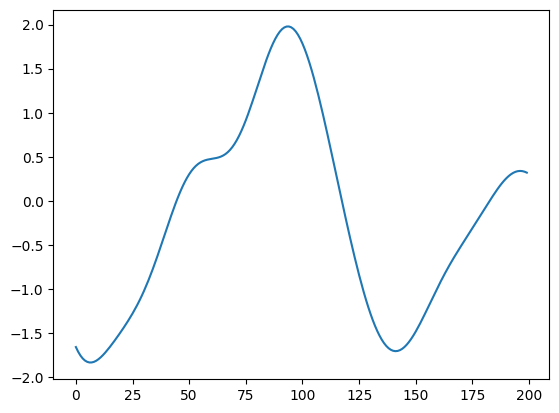

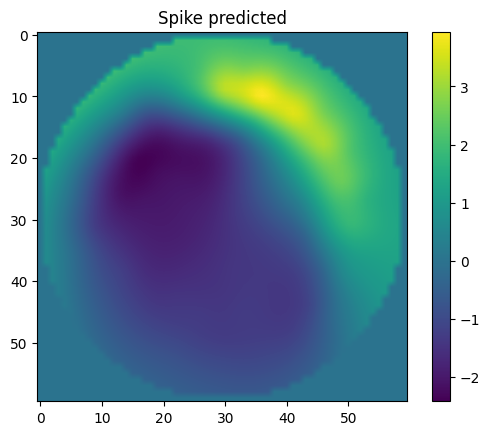

47
9541


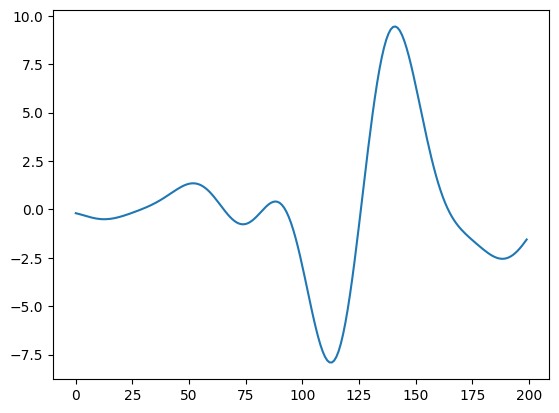

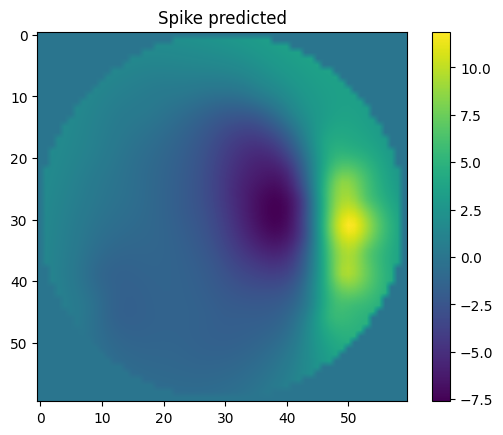

83
16644


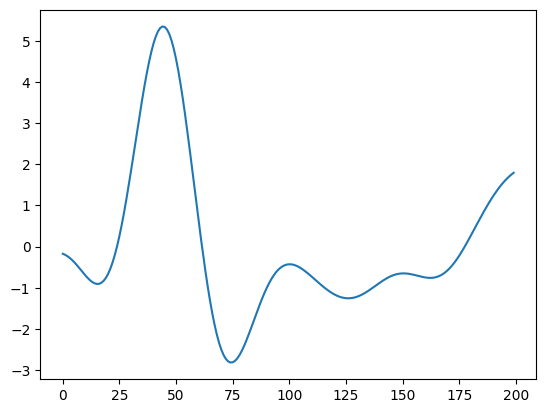

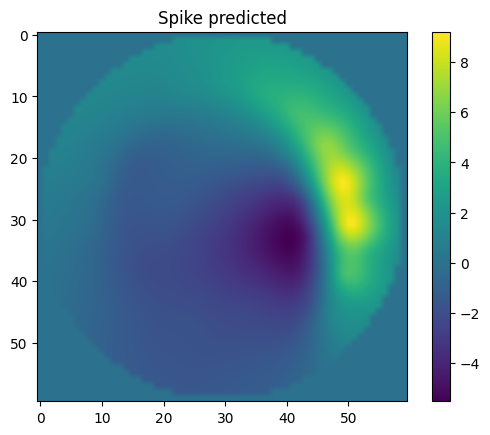

110
22138


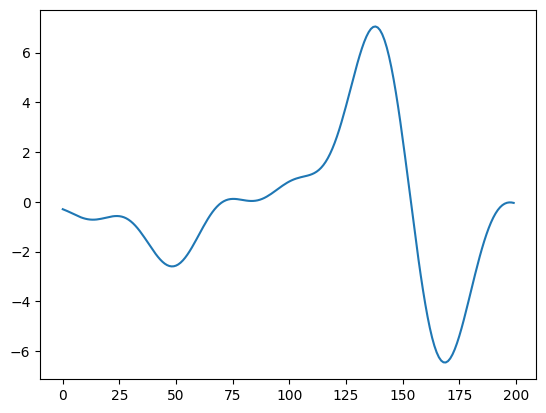

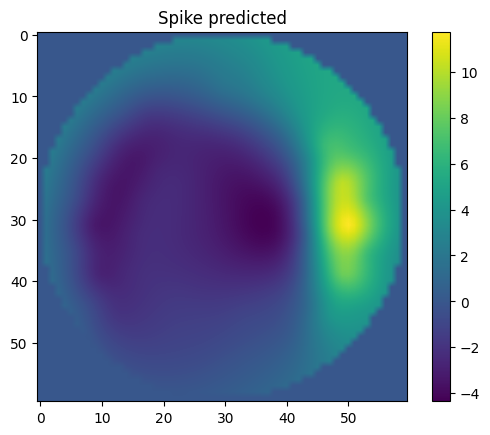

139
27990


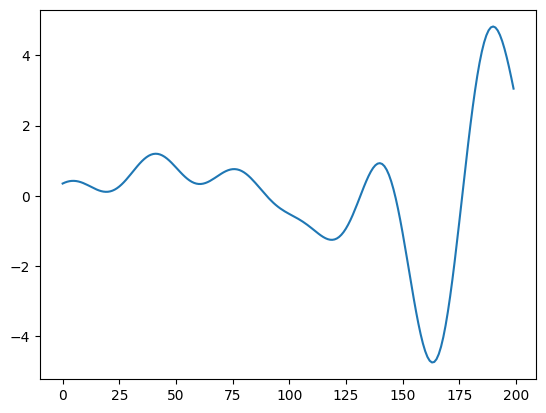

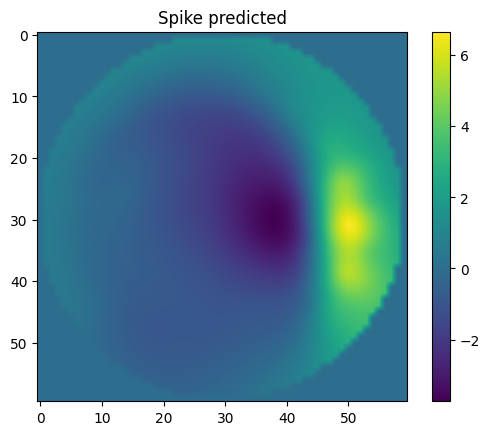

153
30709


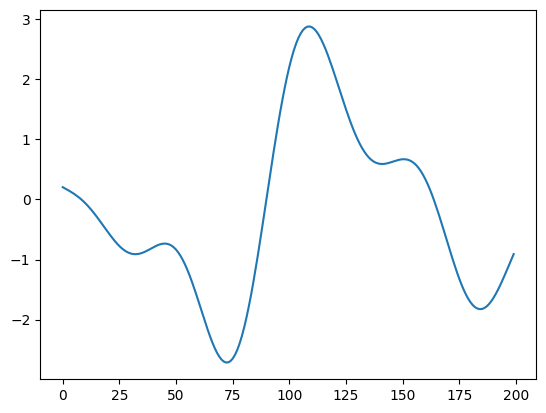

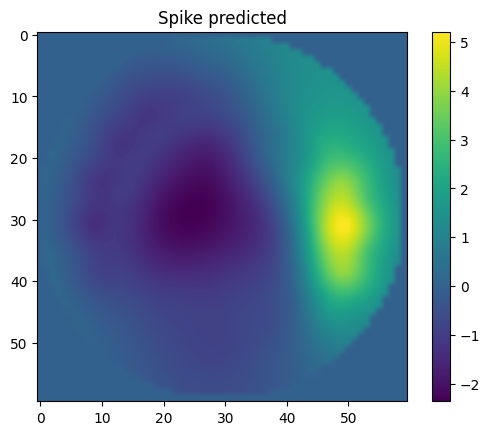

222
44547


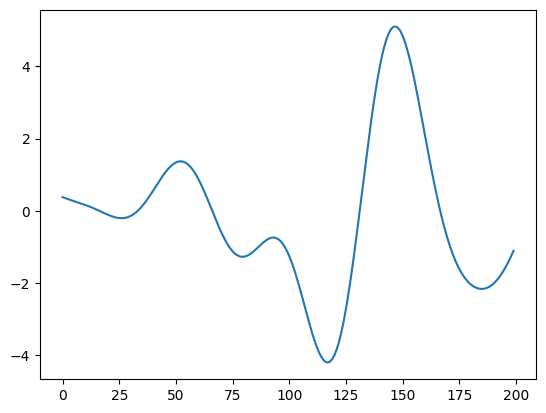

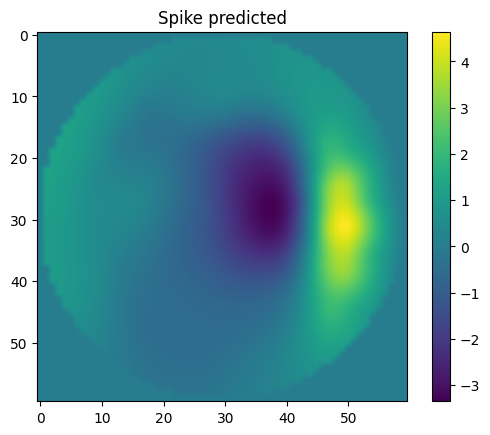

226
45257


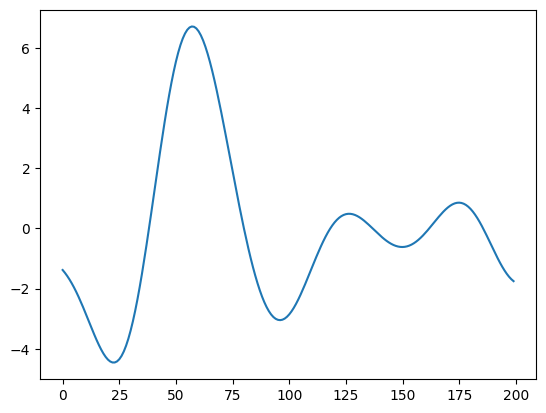

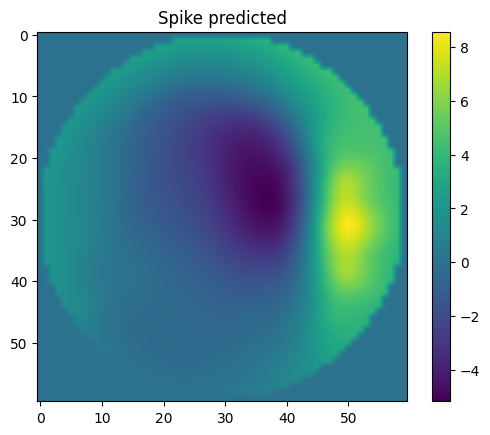

276
55314


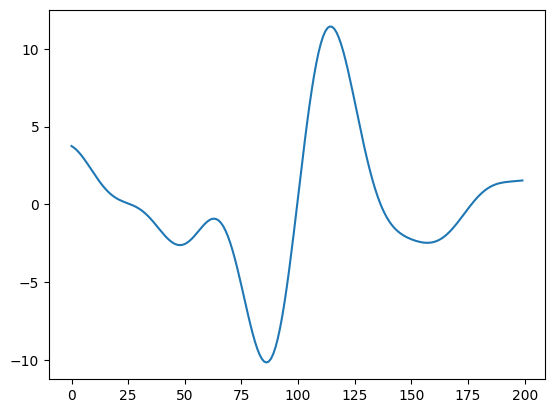

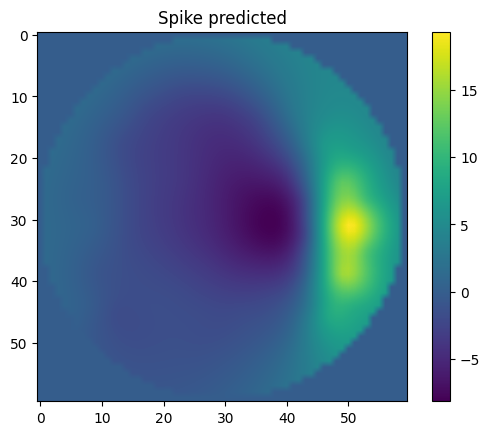

278
55757


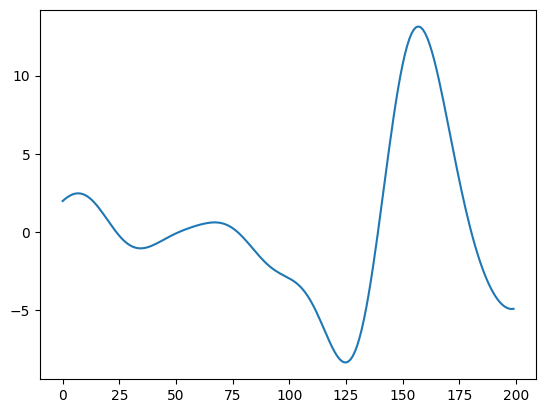

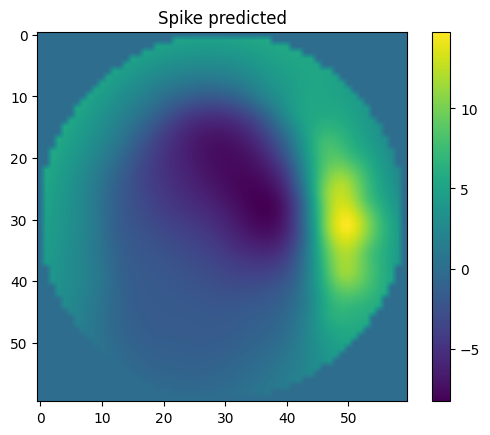

291
58233


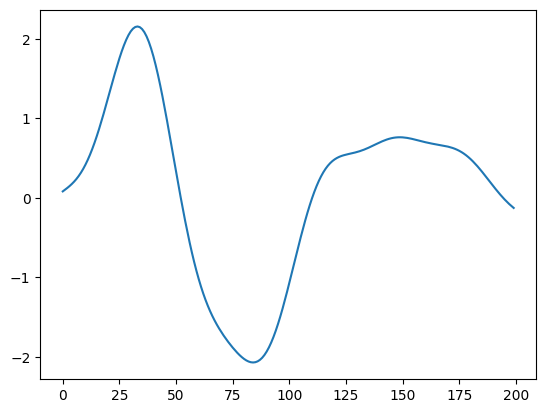

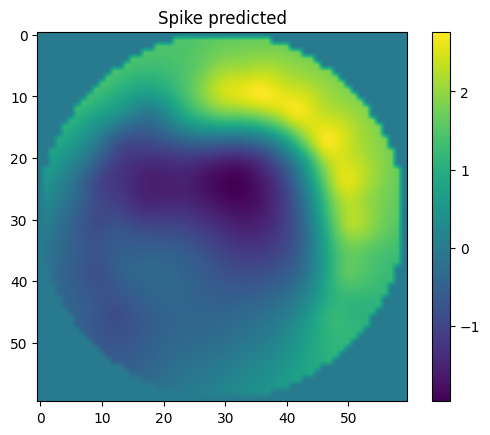

295
59087


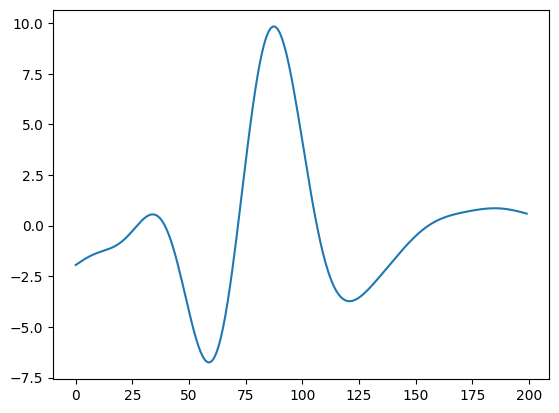

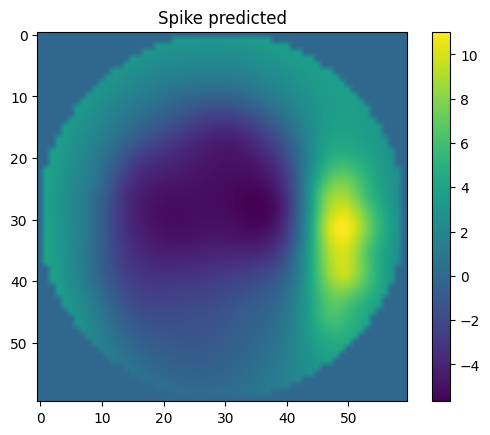

300
60099


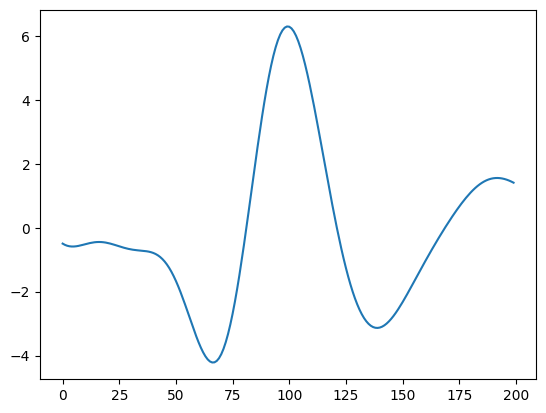

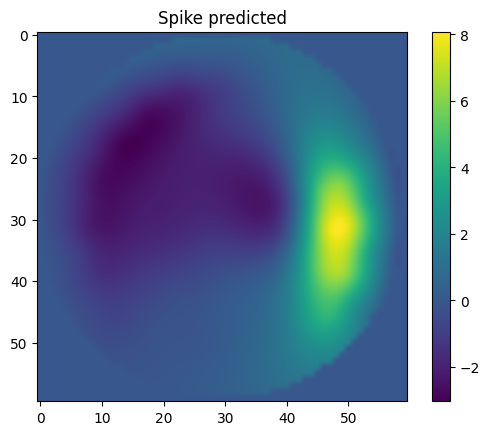

304
60881


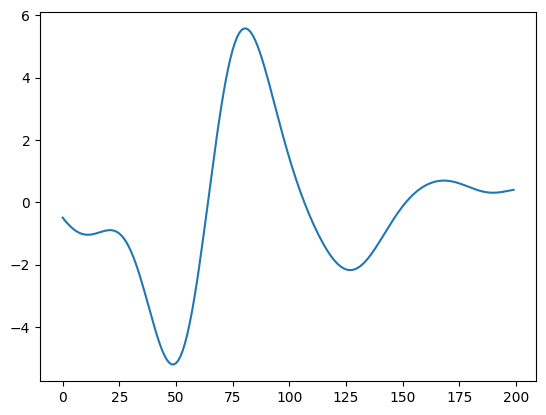

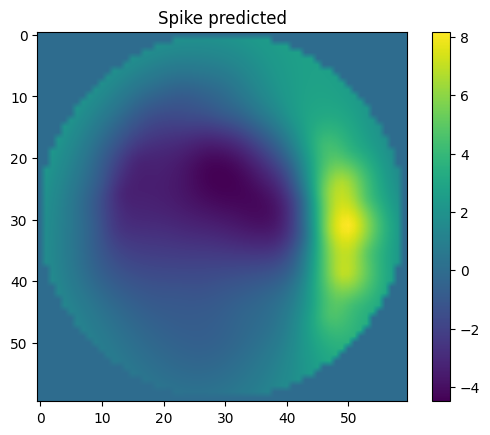

312
62544


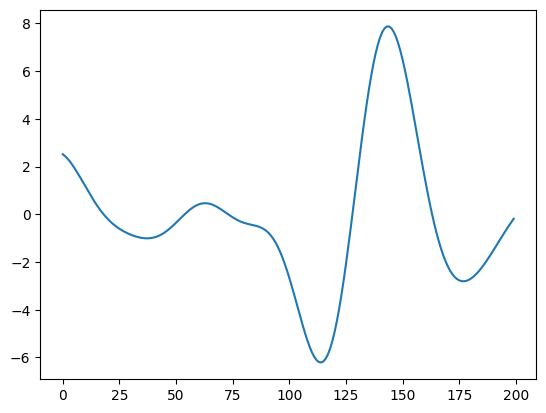

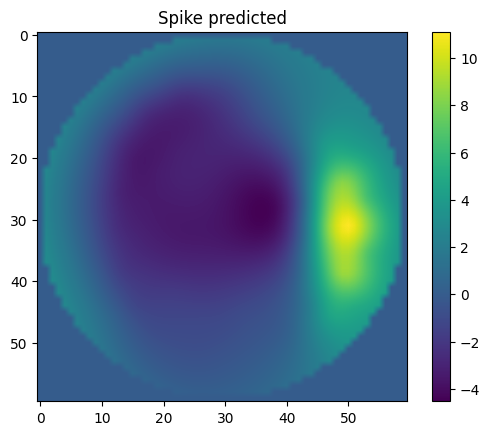

314
62921


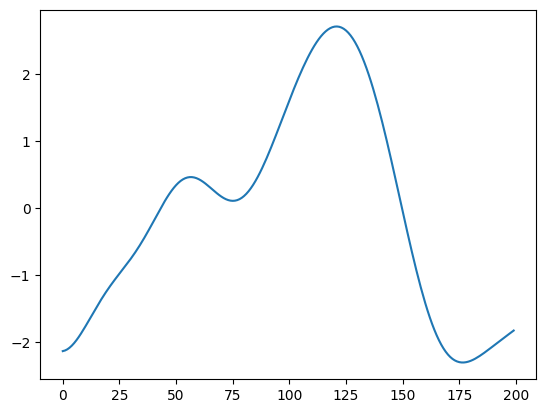

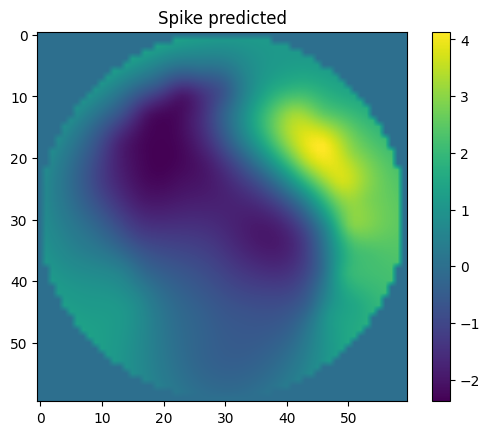

378
75689


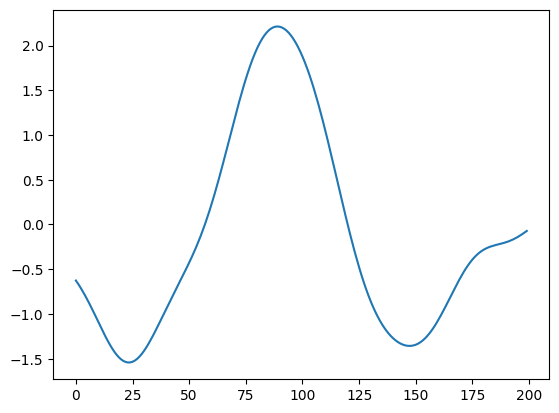

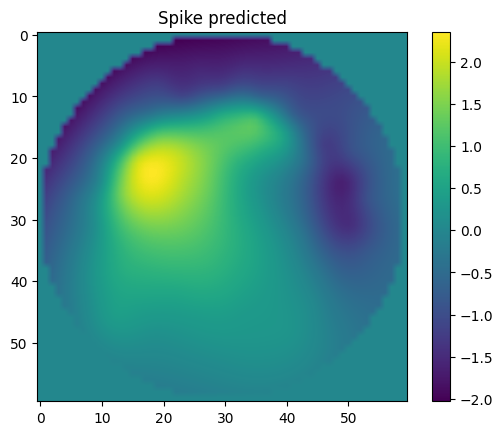

395
79184


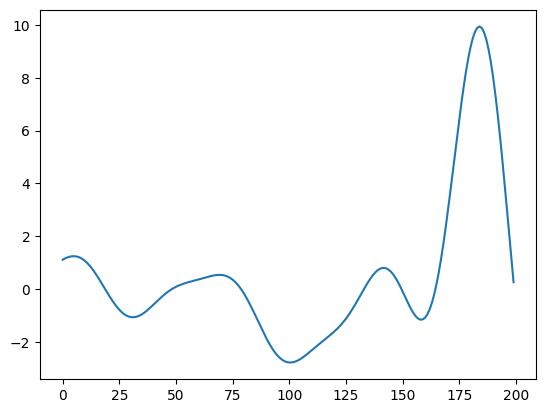

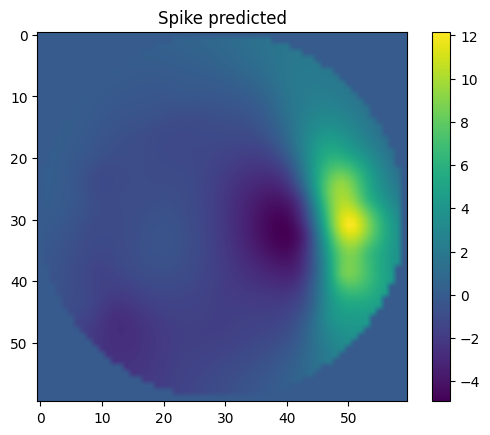

396
79211


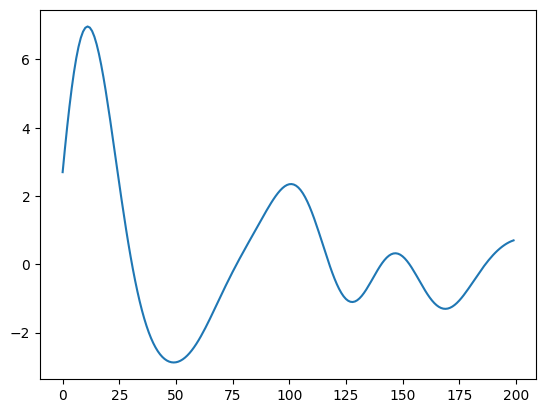

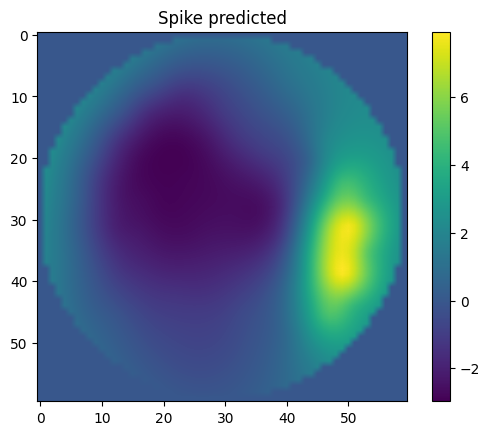

398
79738


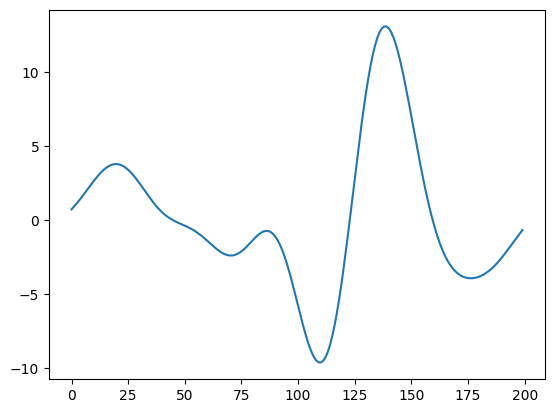

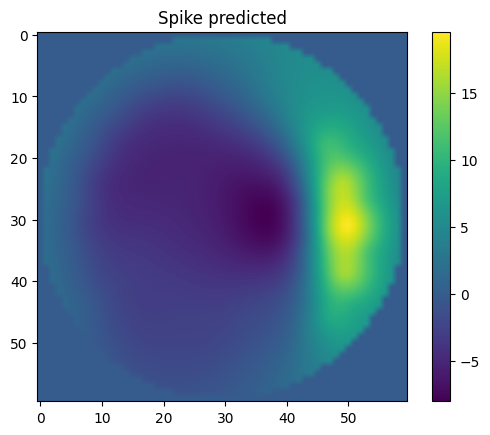

493
98650


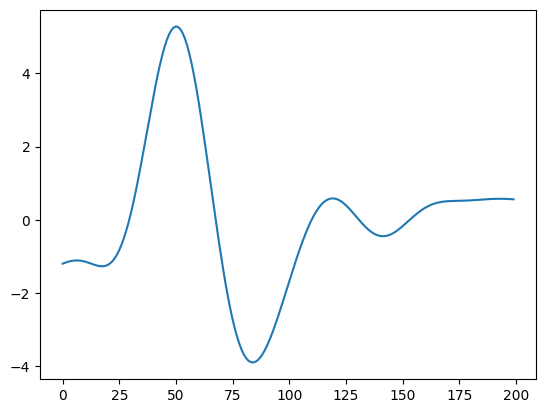

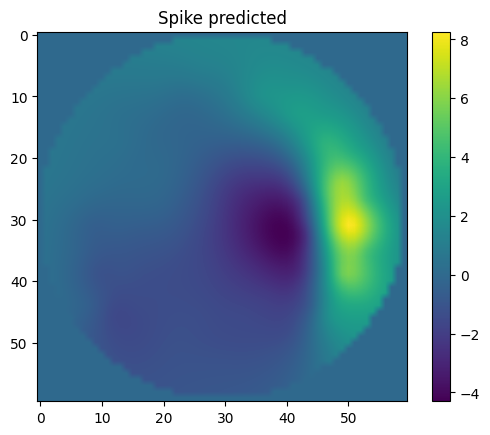

507
101425


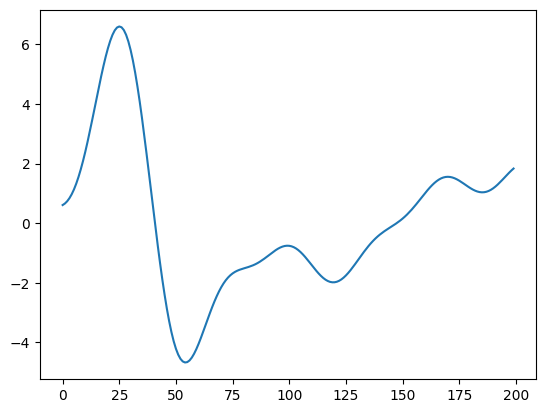

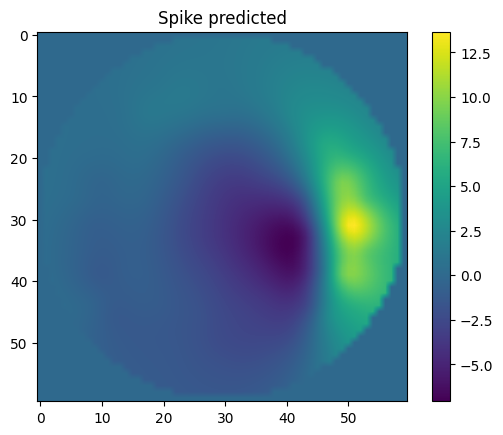

617
123485


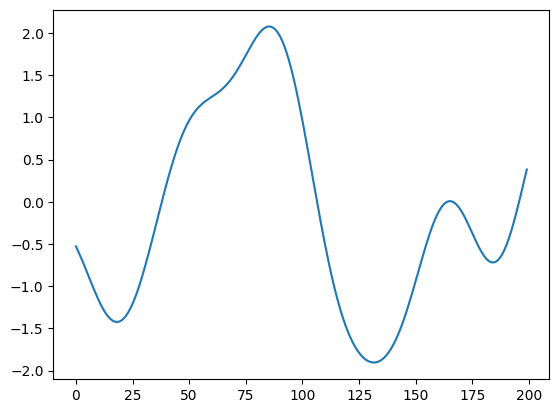

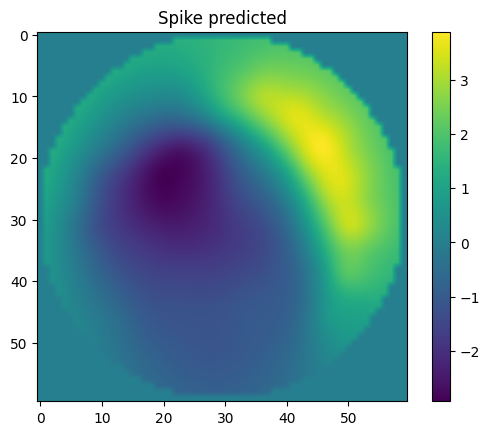

627
125420


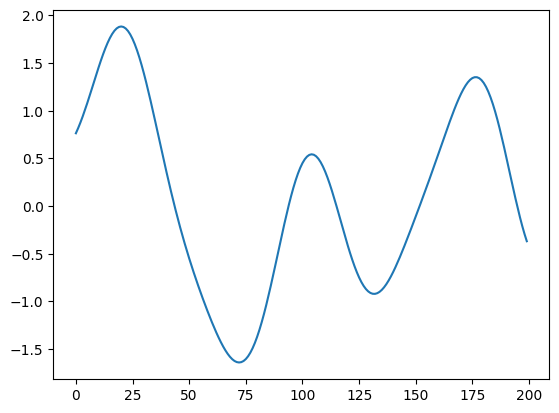

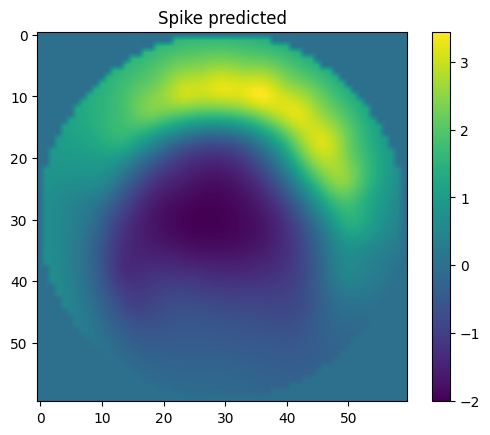

644
128864


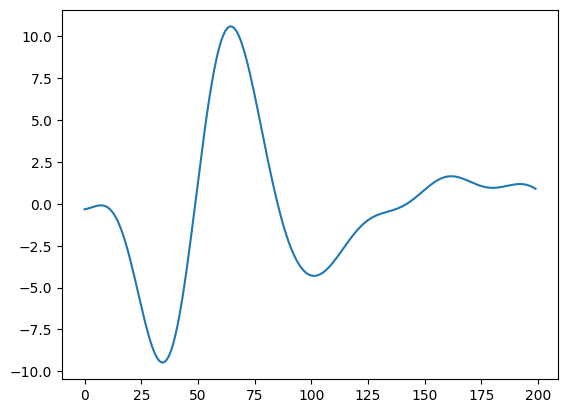

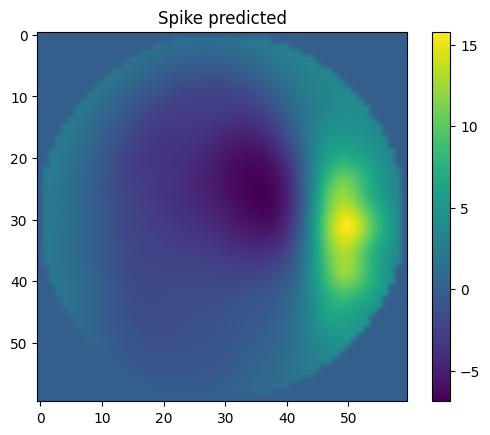

645
129026


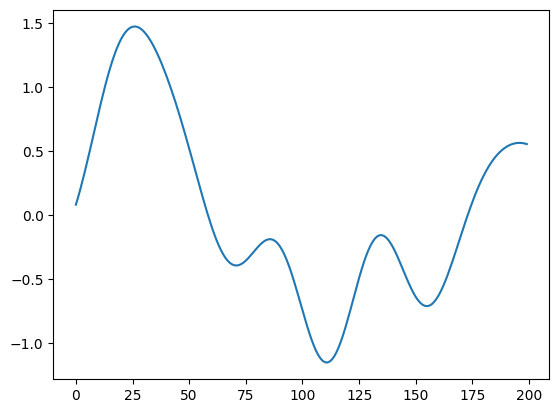

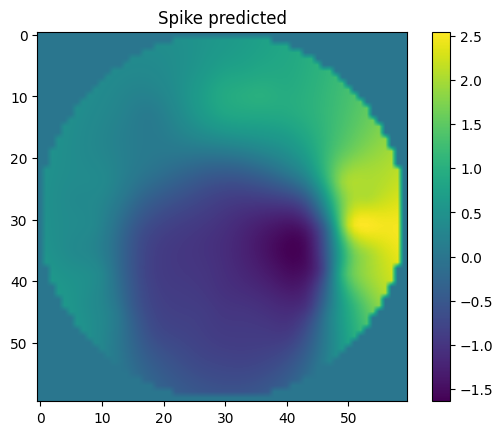

689
137983


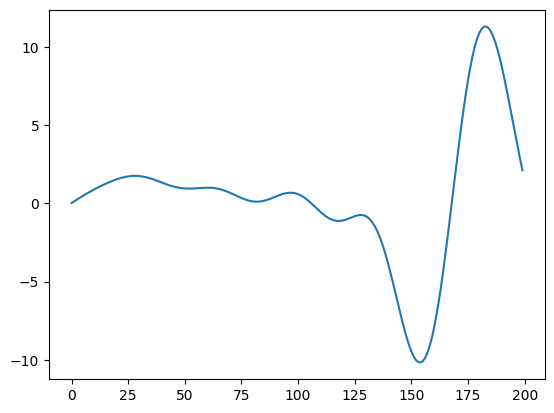

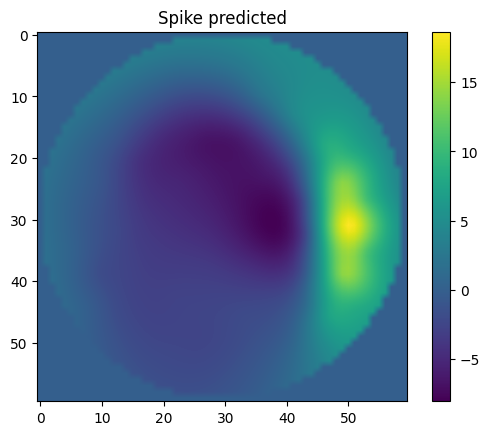

691
138364


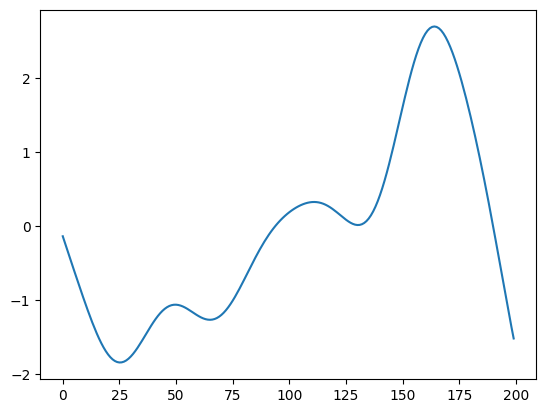

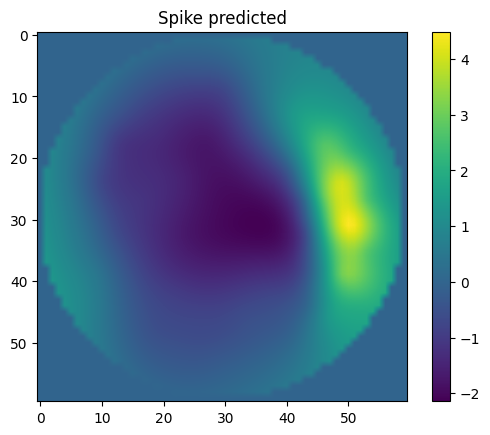

762
152517


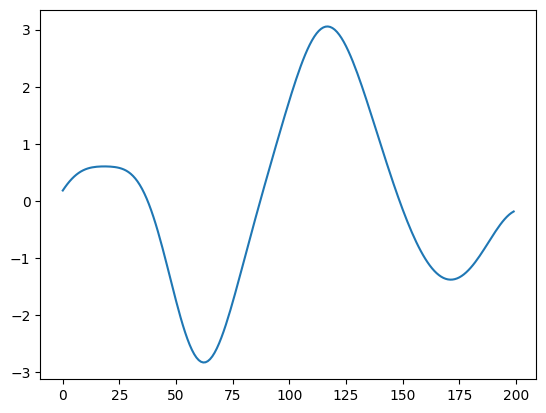

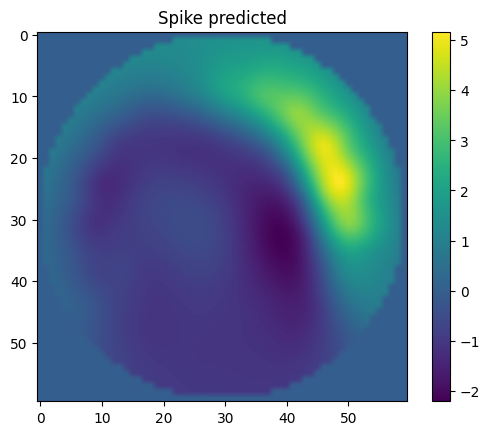

777
155570


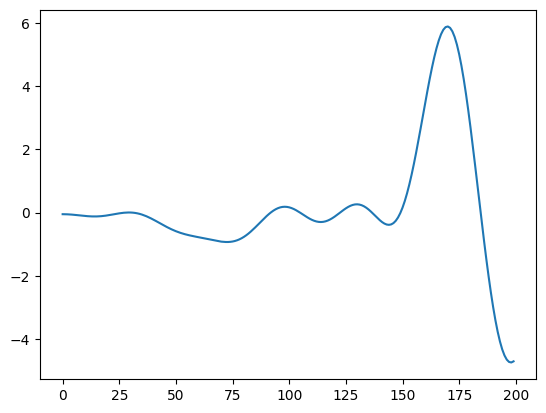

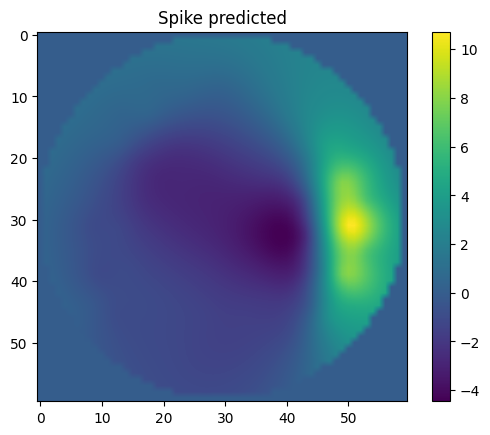

779
155856


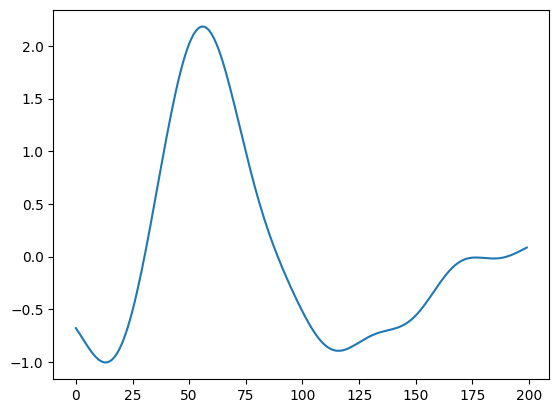

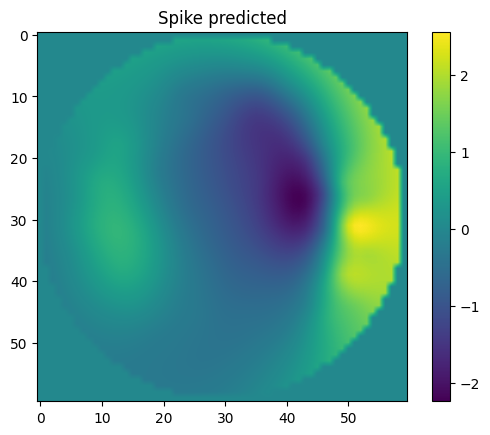

781
156310


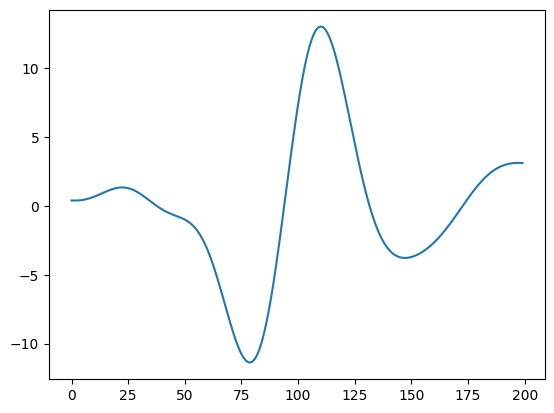

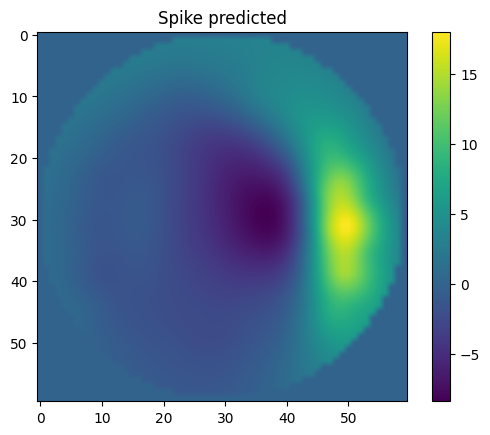

818
163728


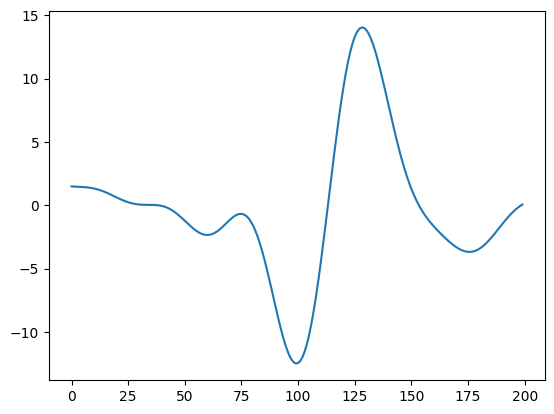

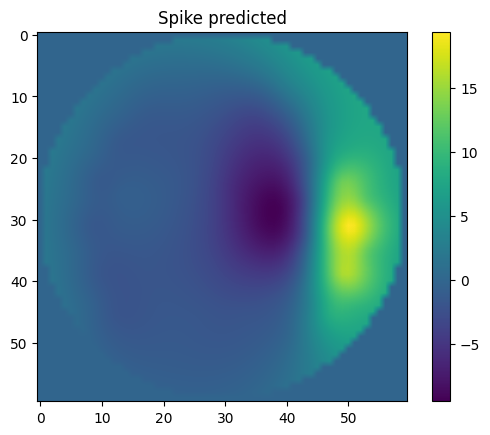

823
164762


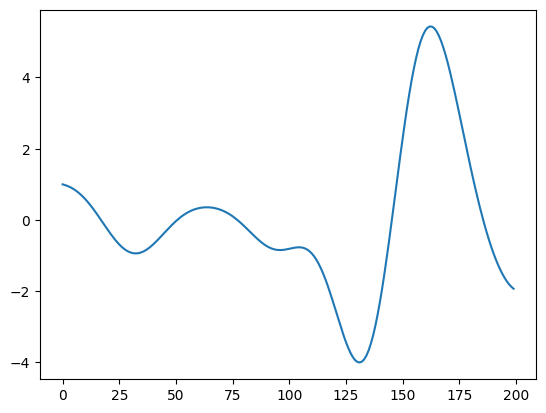

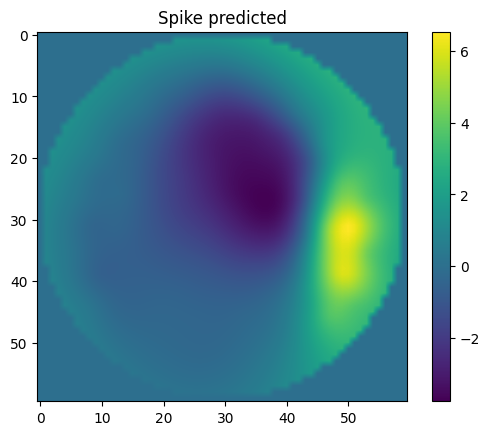

828
165726


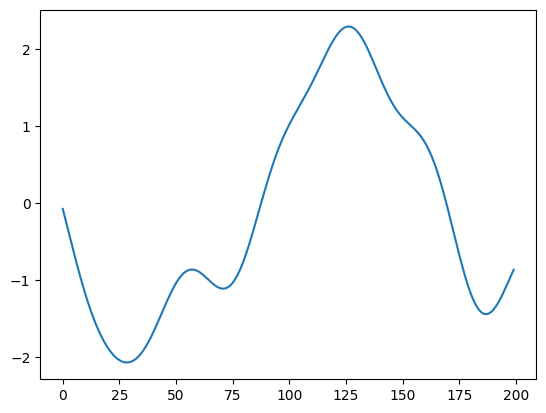

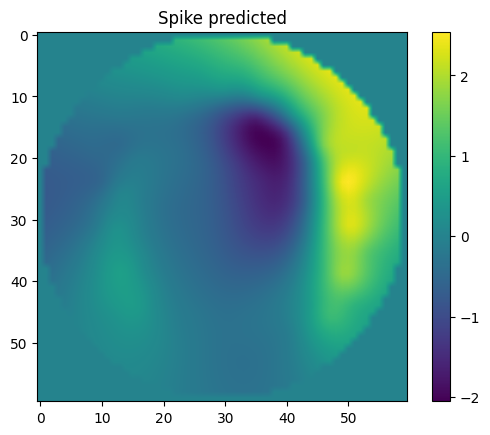

853
170782


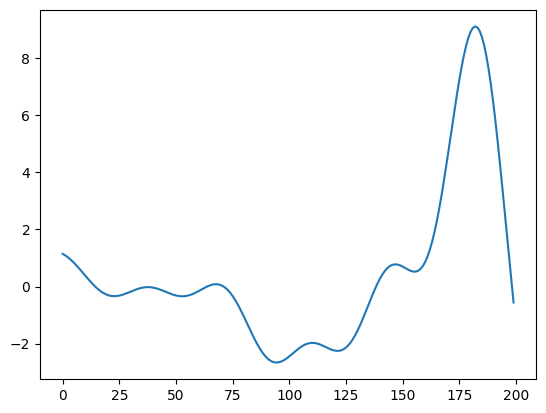

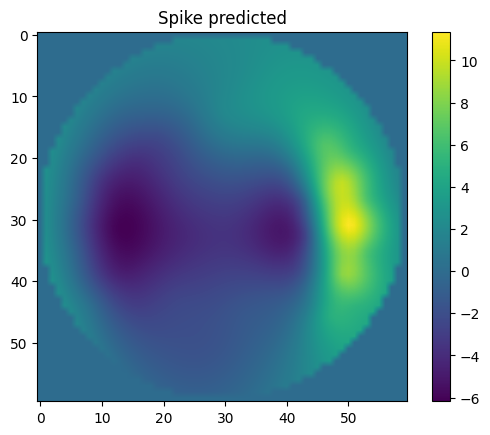

854
170810


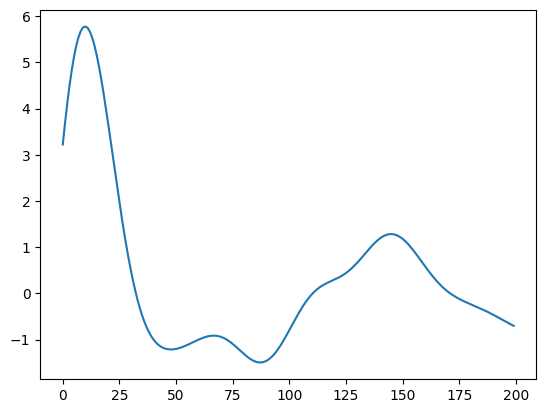

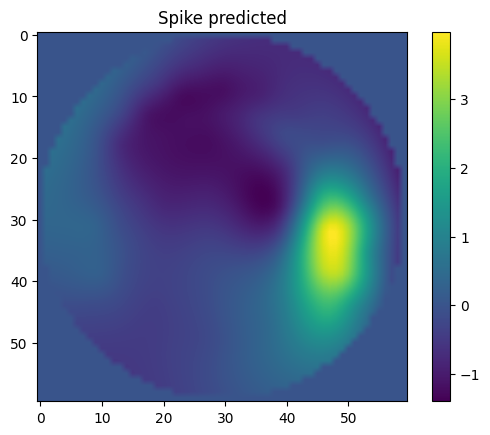

961
192380


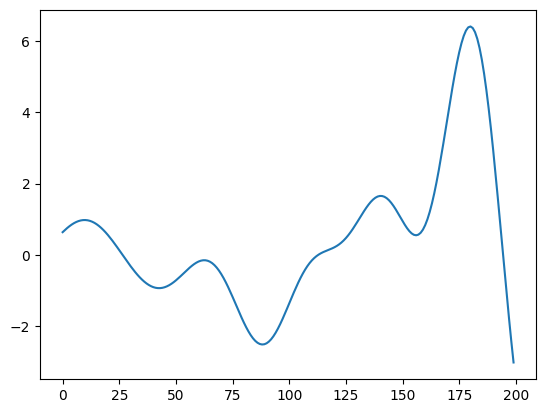

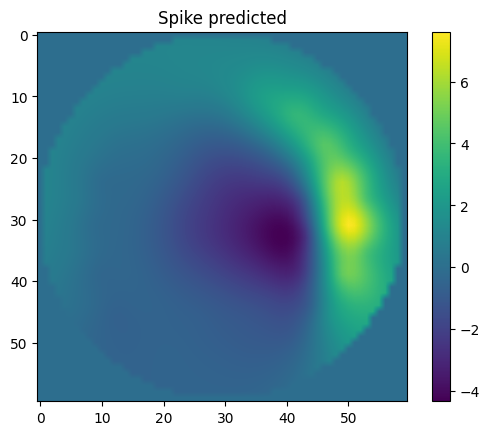

962
192409


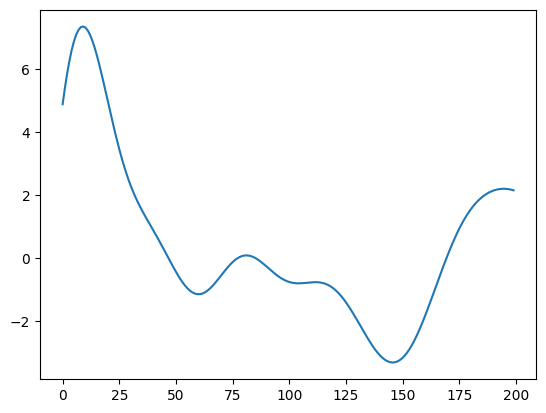

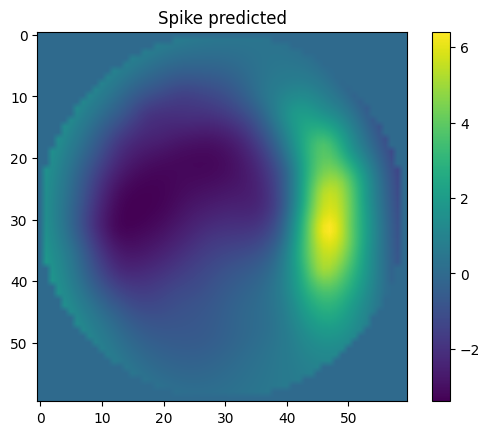

1002
200574


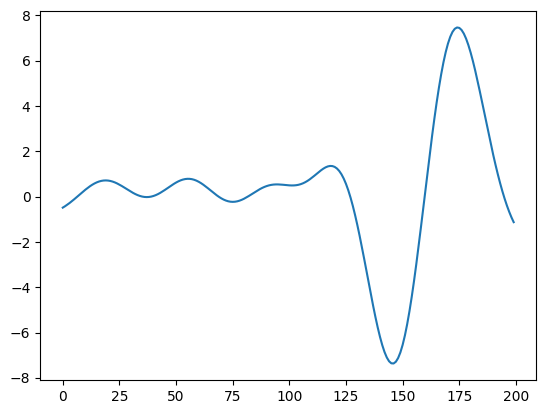

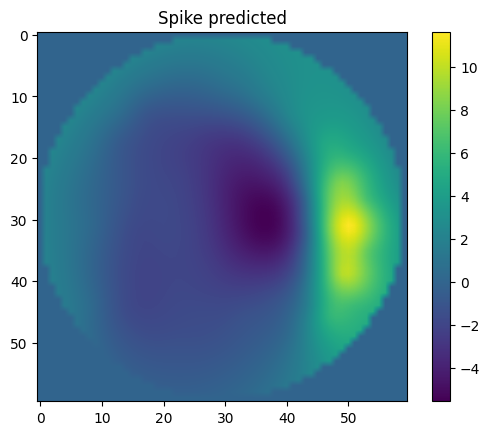

1021
204320


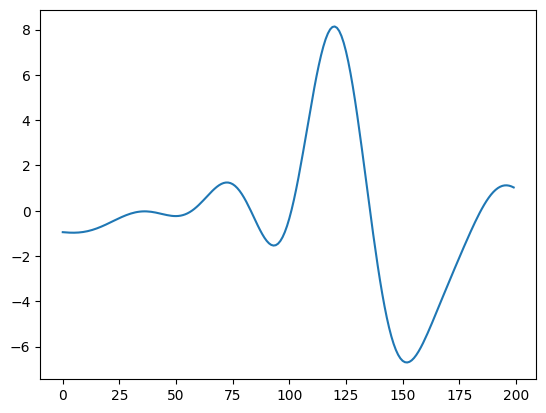

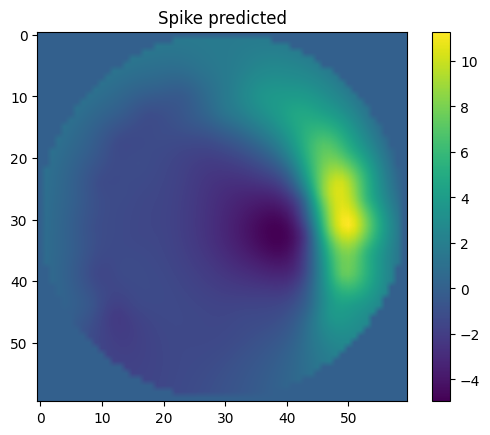

1023
204734


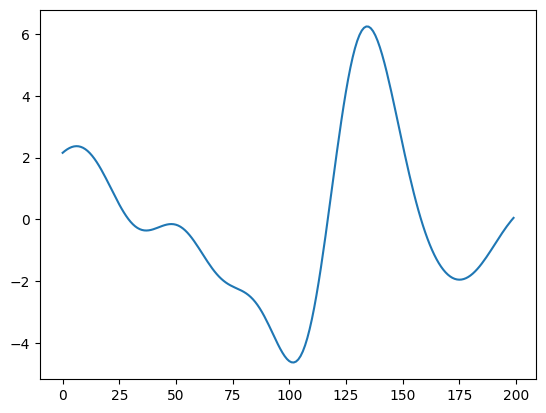

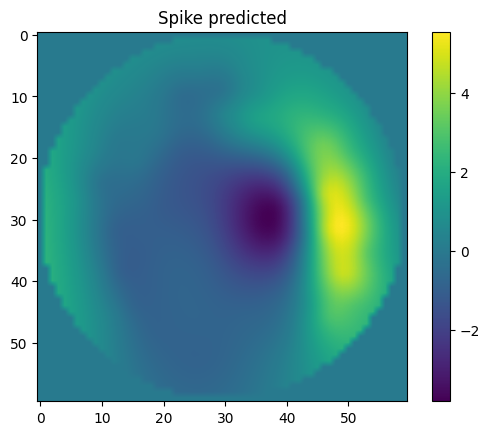

1075
215101


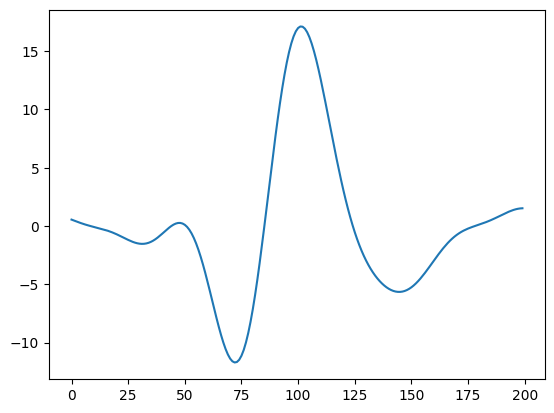

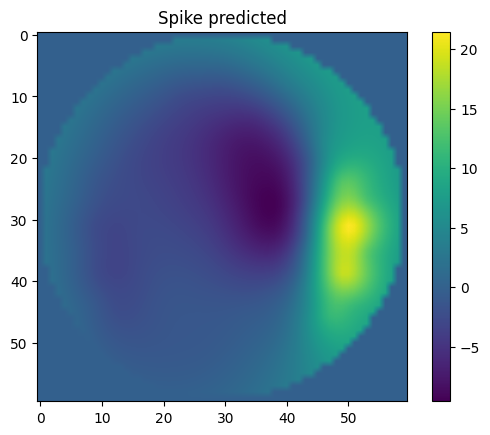

1076
215357


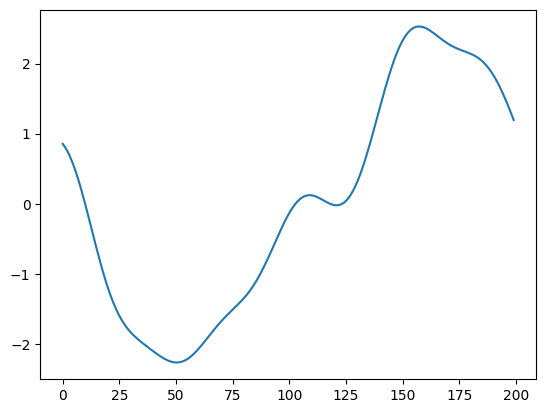

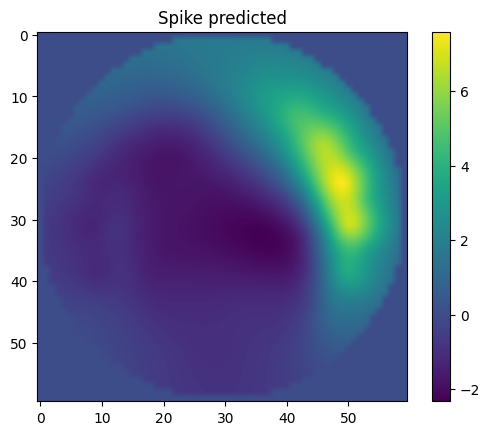

1077
215473


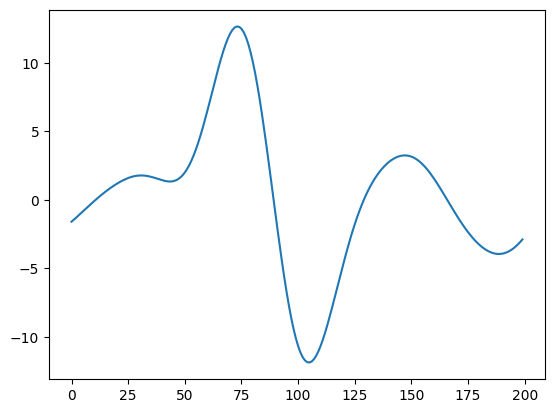

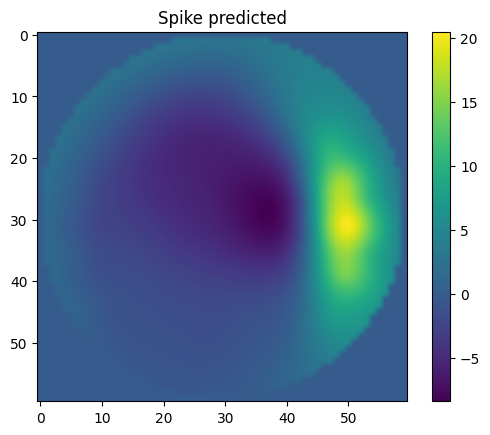

1094
218966


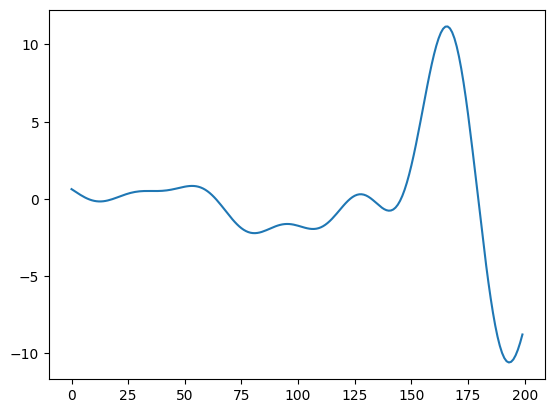

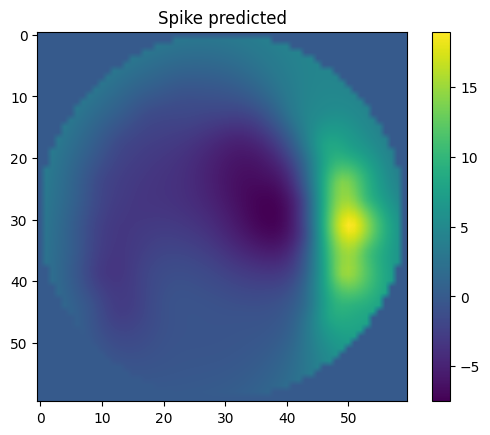

1103
220729


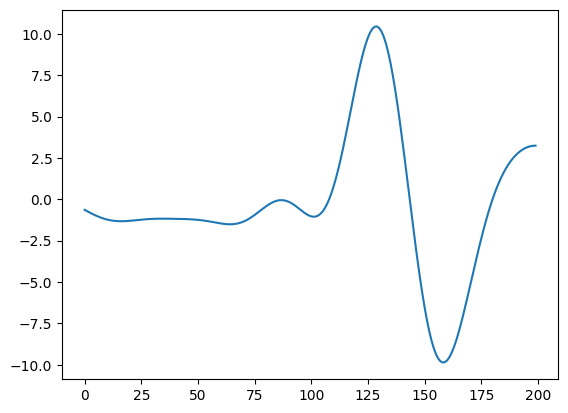

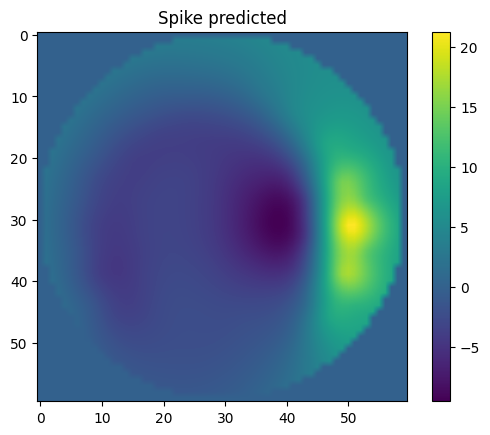

1130
226057


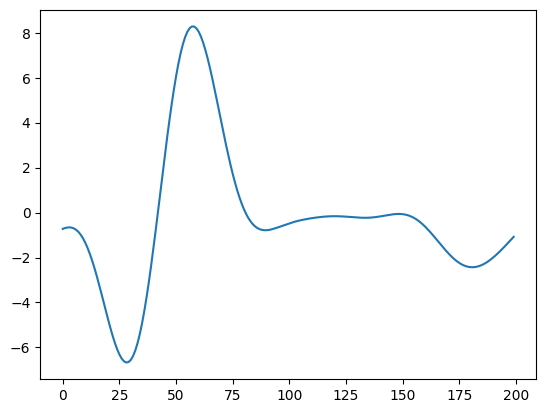

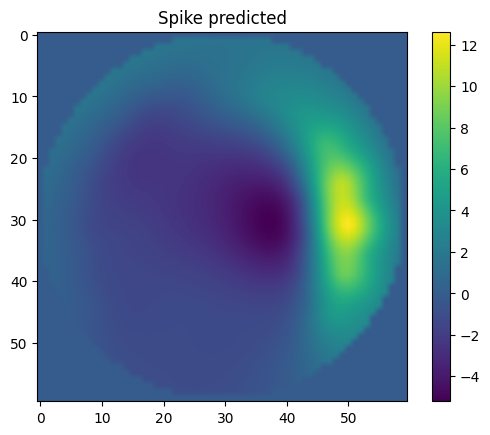

1144
228990


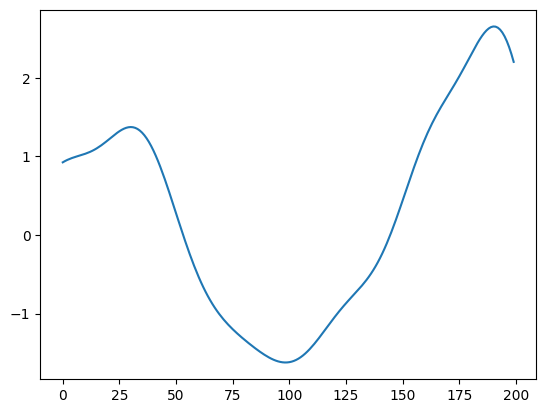

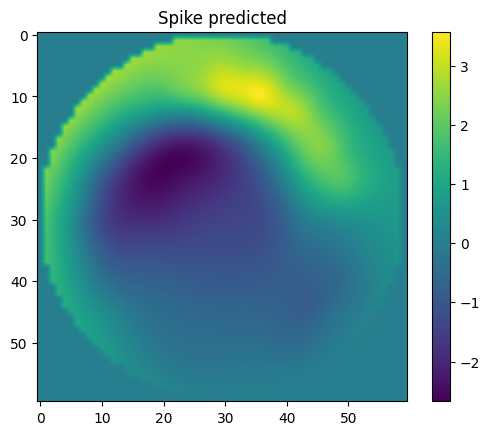

1147
229460


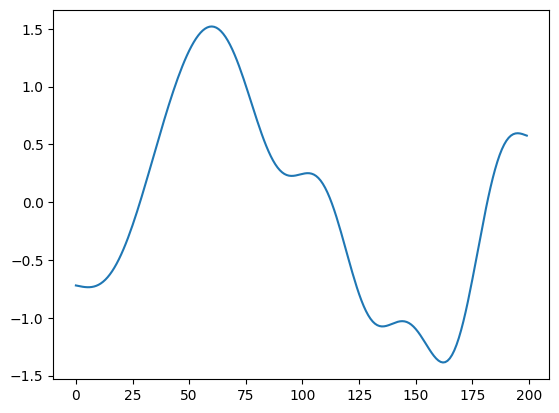

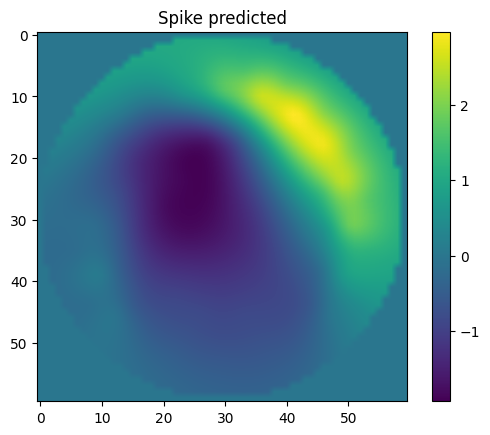

1163
232780


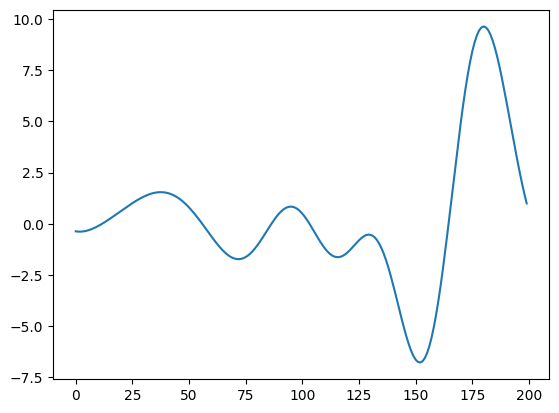

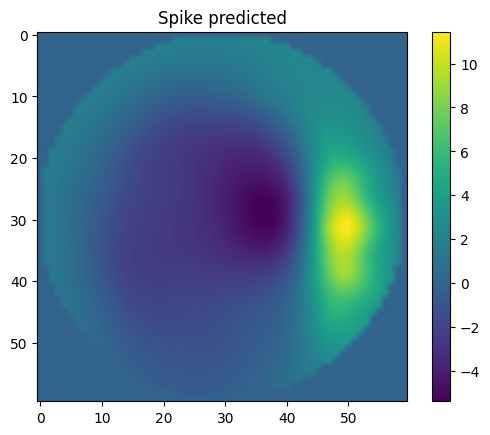

1167
233593


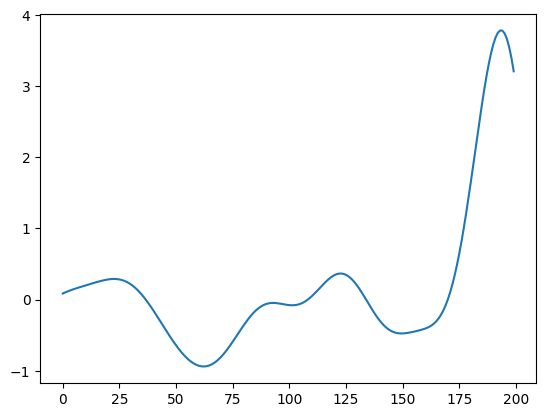

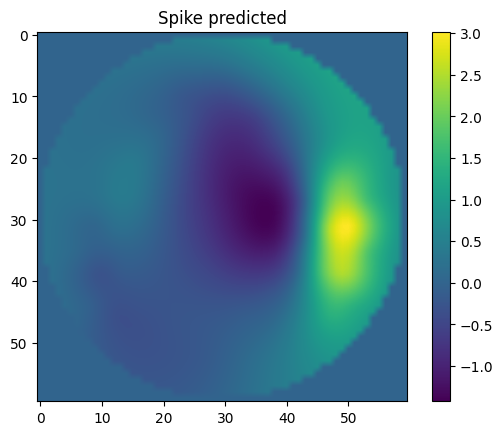

1168
233625


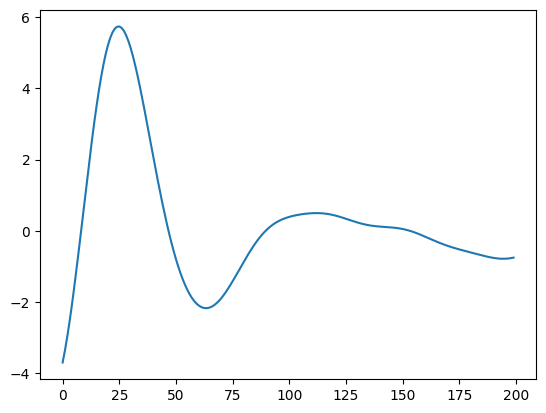

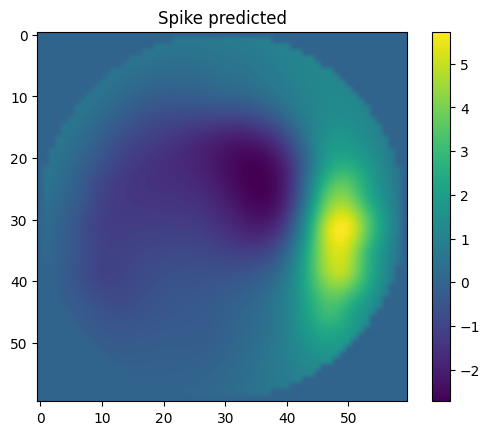

1181
236296


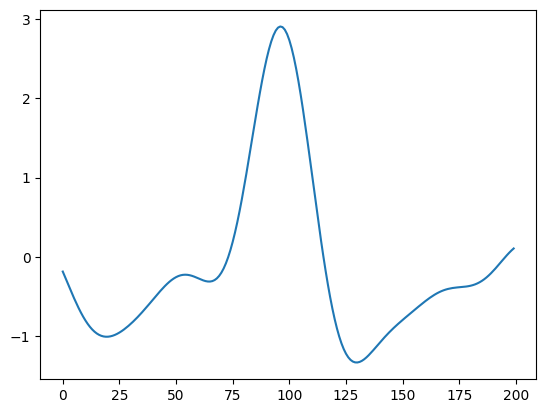

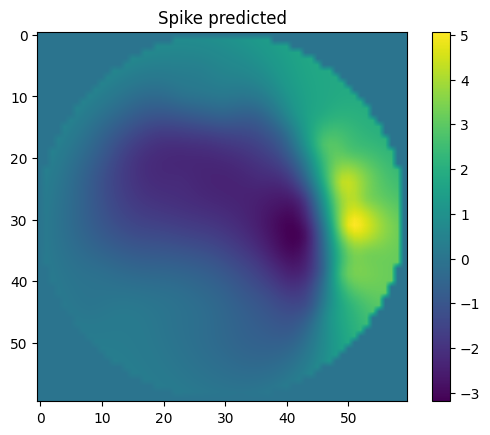

1206
241356


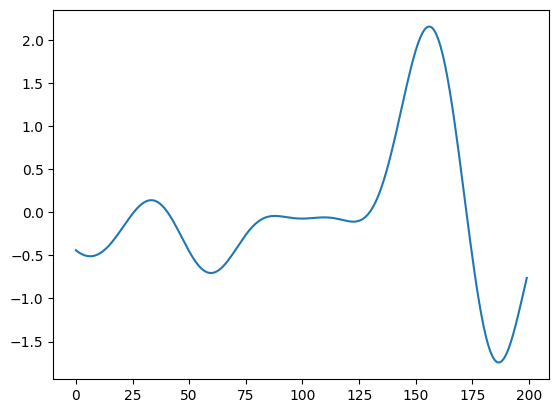

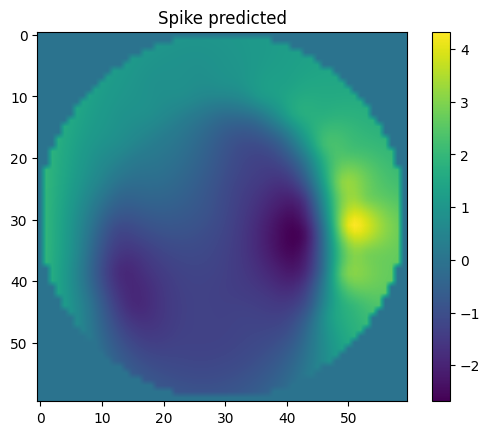

1217
243535


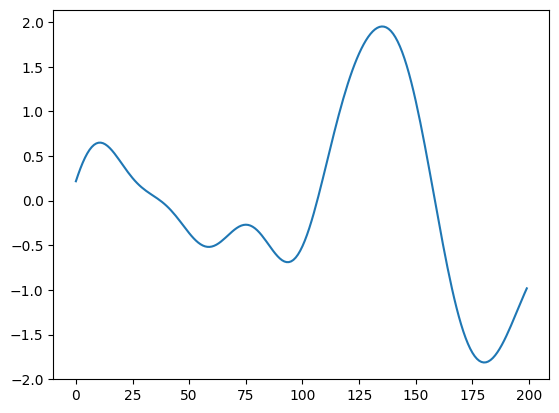

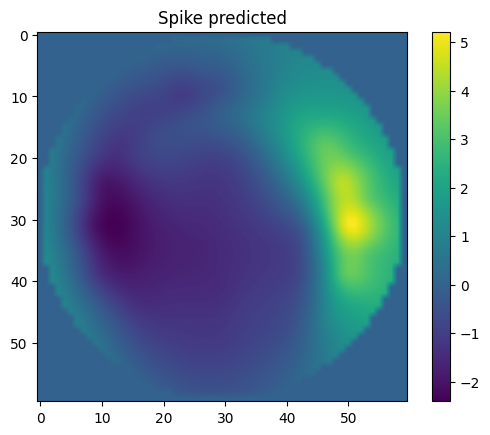

1260
252109


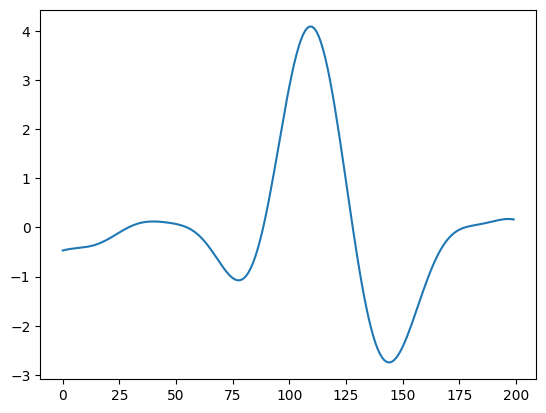

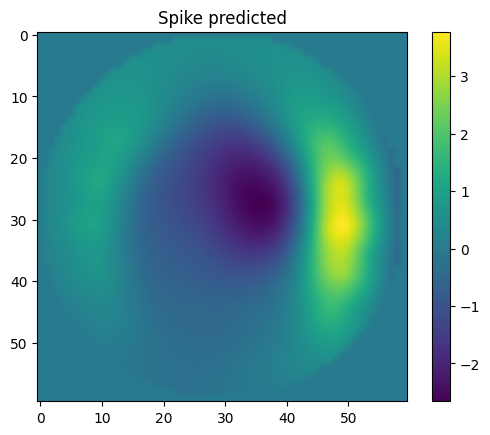

1289
257956


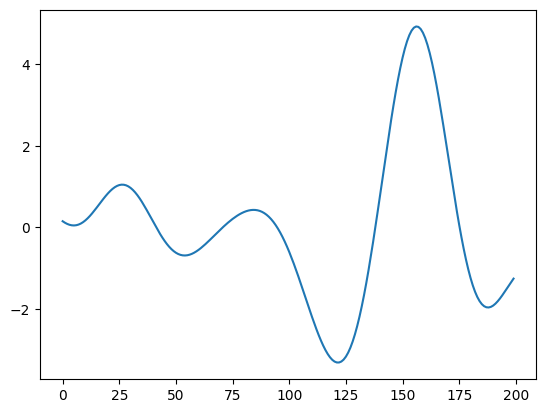

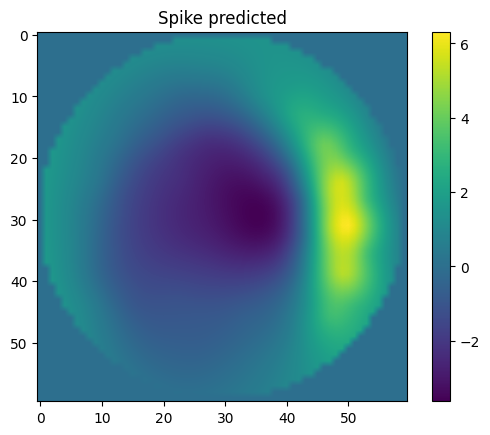

1386
277245


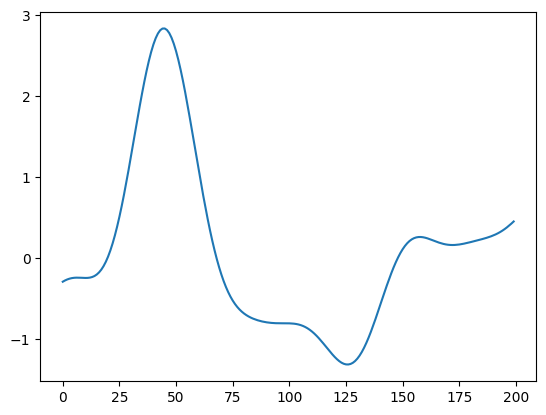

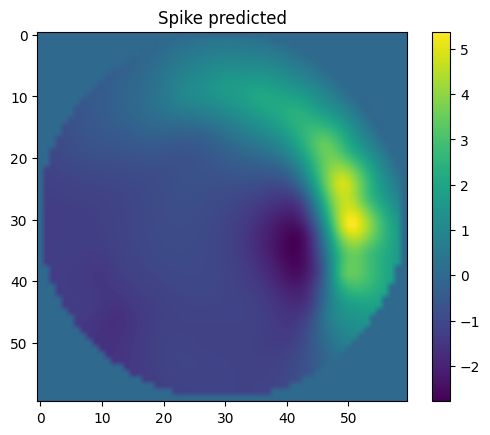

1413
282744


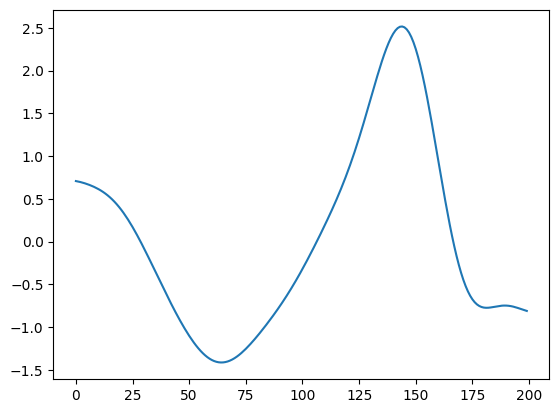

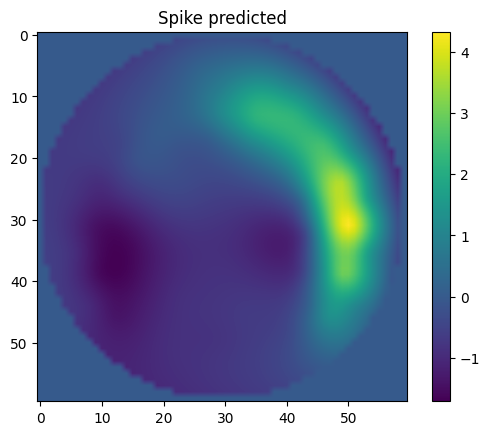

1441
288259


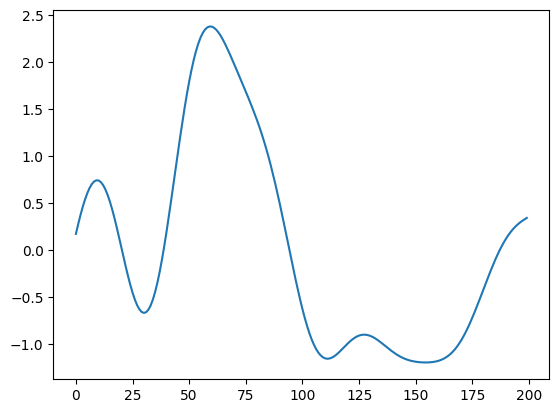

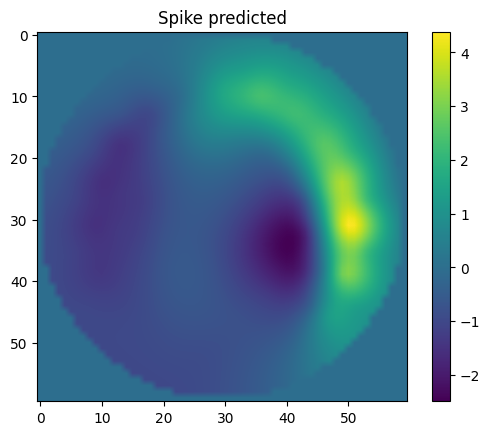

1467
293597


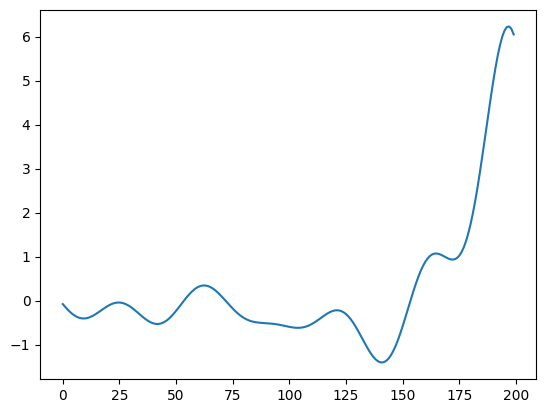

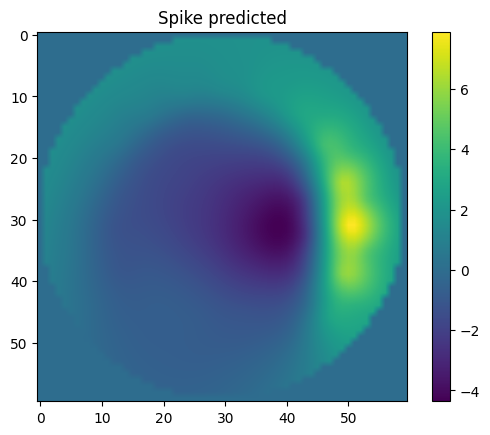

1468
293624


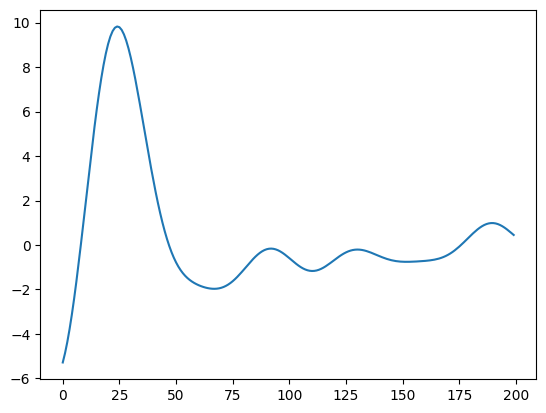

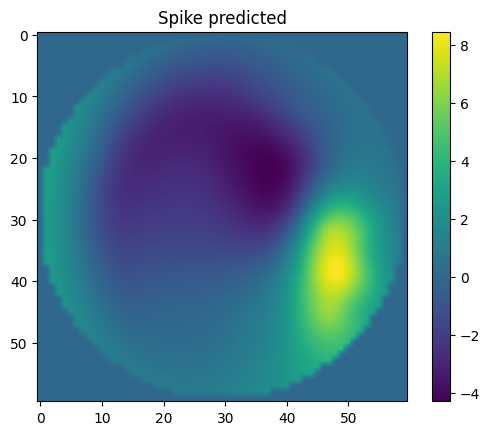

1469
293874


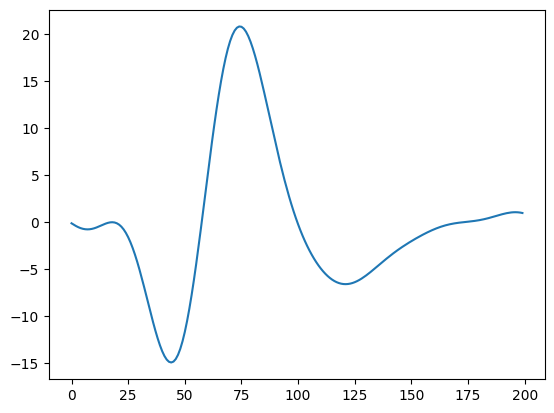

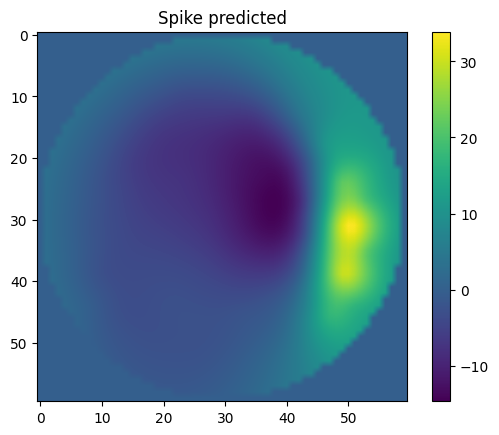

1471
294319


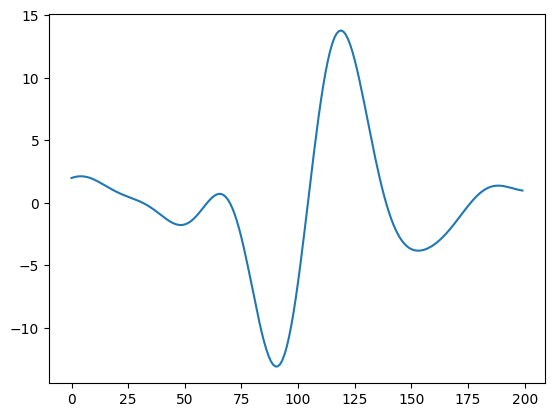

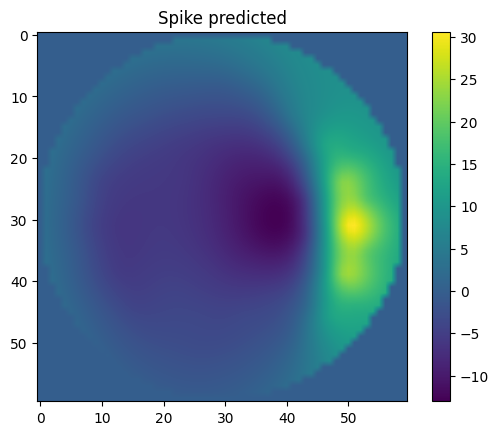

1473
294763


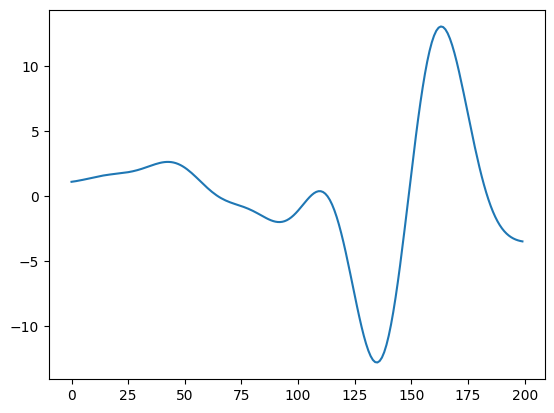

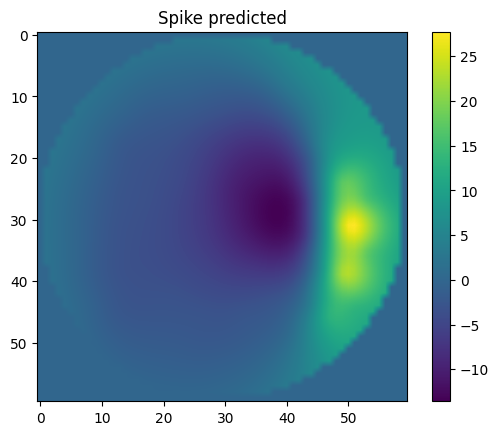

1474
294824


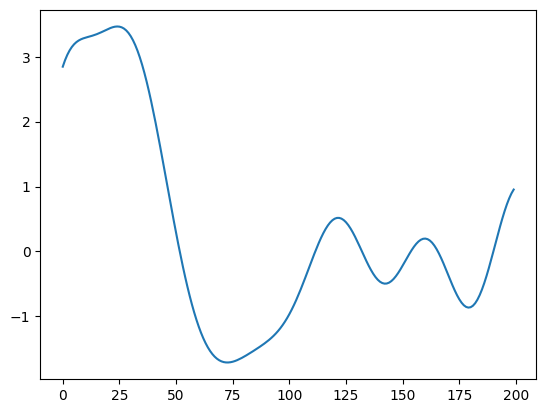

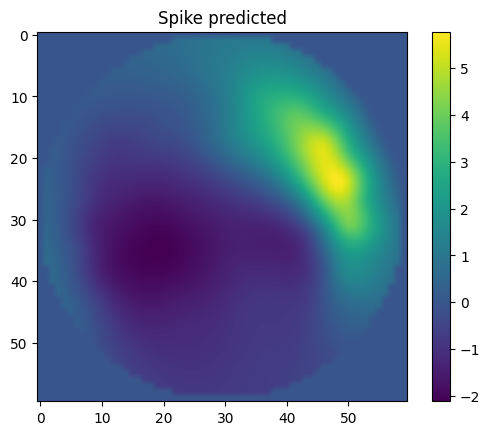

1479
295980


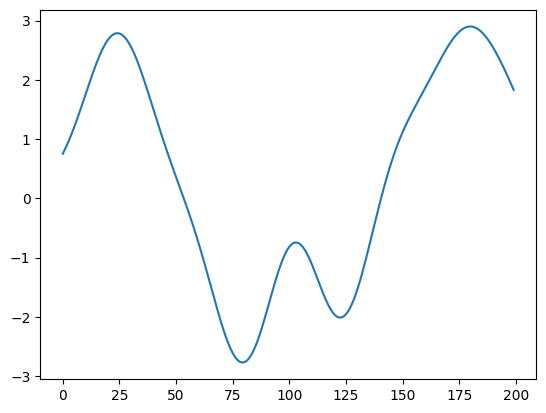

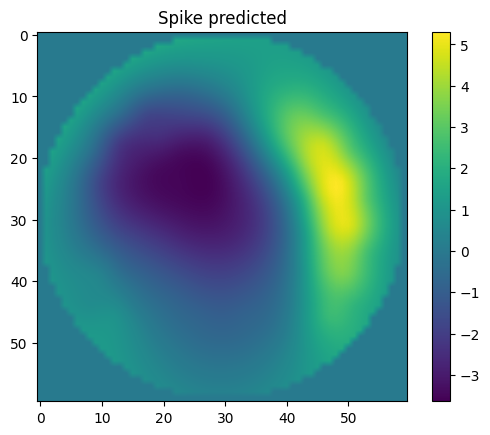

1501
300300


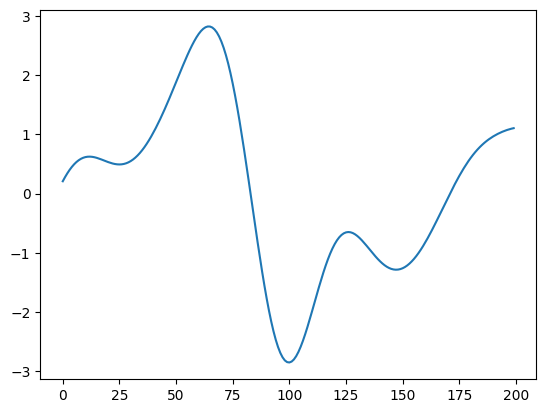

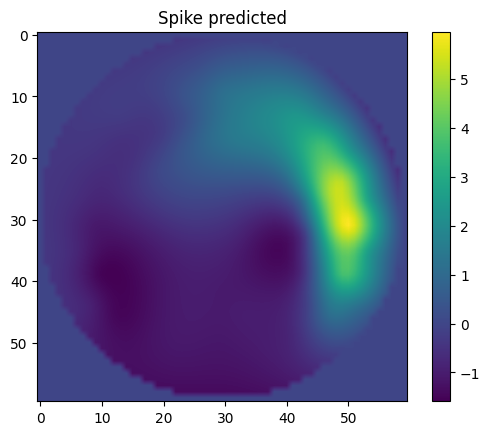

1505
301157


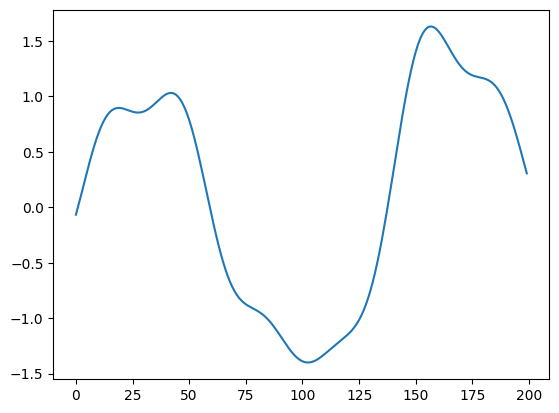

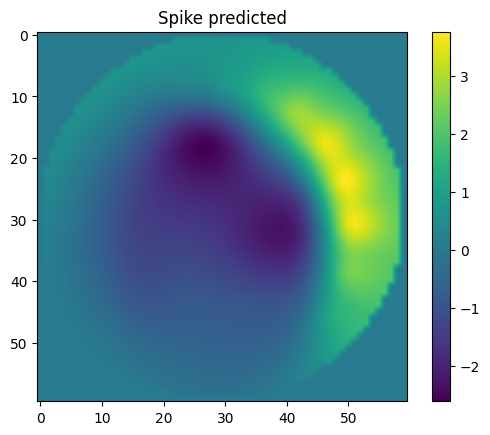

1535
307124


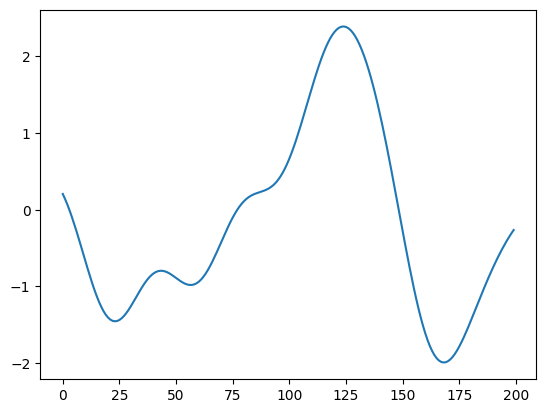

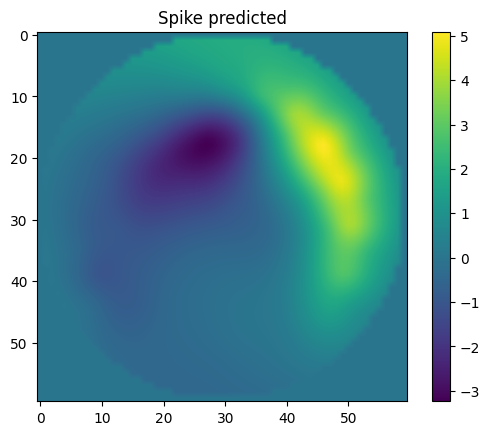

1541
308267


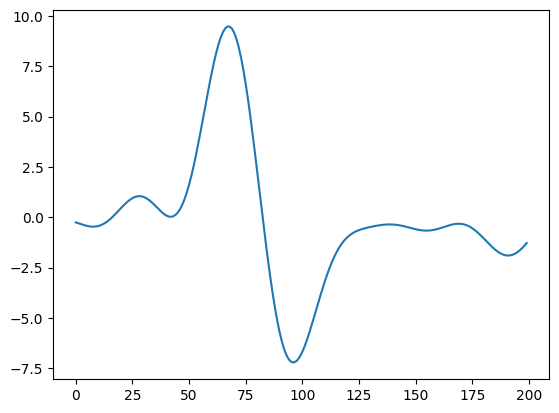

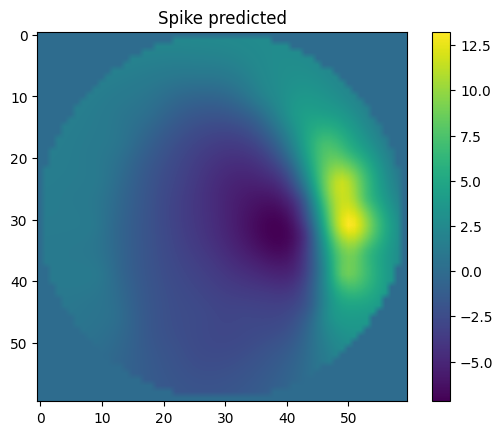

1542
308558


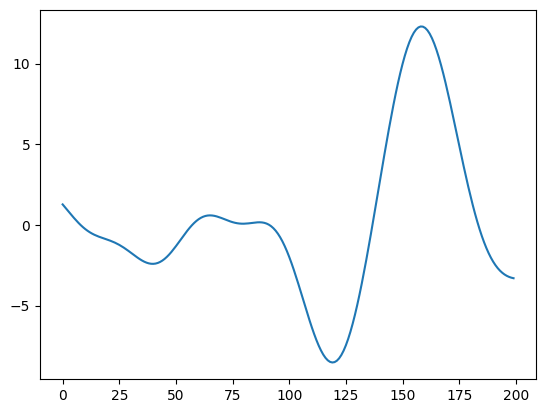

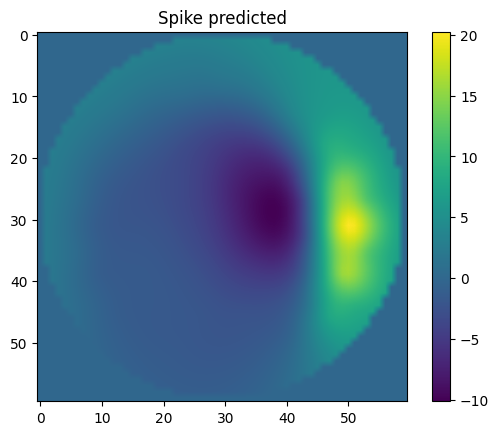

1544
308925


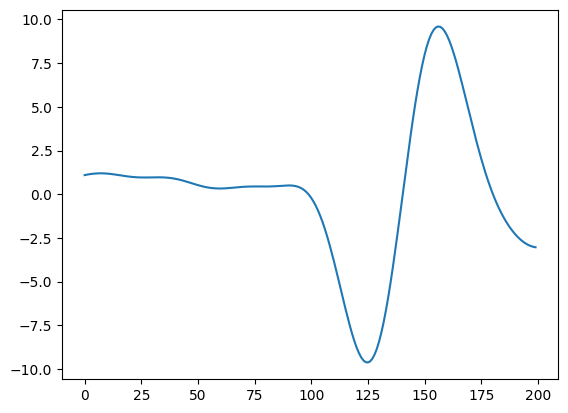

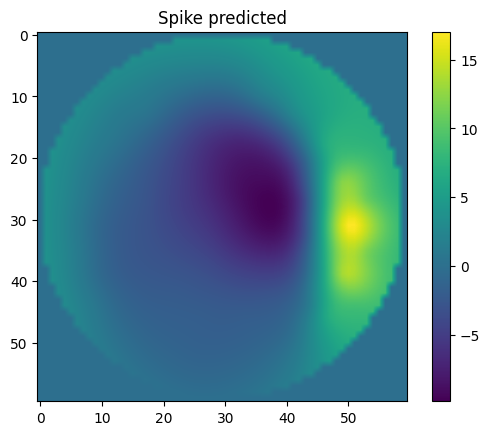

1545
309048


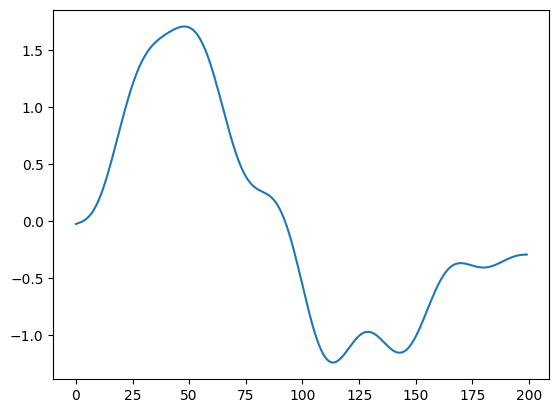

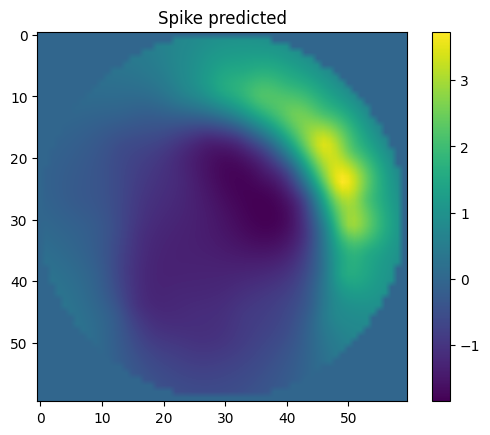

In [27]:
# Spikes predicted 

n_timesteps = 200
i=-1
for id in index_pred:
    print(id)
    i = i + 1
    print(spike_real_time[i])
    
    plt.plot(range(n_timesteps),t_data[id,0:n_timesteps])    
    plt.show()

    plt.imshow(z_data[id,:,:], interpolation='bilinear')#,vmin=-4.0,vmax=4.0)    
    plt.colorbar()
    plt.title("Spike predicted")
    plt.show()